### Senario 2
read birth data and try predict weight and heaight and bmi for 6m, then compare DeltaZ and also test by 6m.csv data for validation of weight and height and bmi preidicted

Train and evaluate models that predict next-age z-scores for BMI, height and weight.

Usage:
    python train_and_evaluate.py

This script will:
 - load age CSV files from the current directory (birth.csv, 6m.csv, 12m.csv, ...)
 - iterate transitions (birth->6m, 6m->12m, ...)
 - for each transition, merge on 'national_id', select available z-score columns (current & next)
 - train 4 regressors per target z-score: LinearRegression, SVR, XGBRegressor, MLPRegressor
 - compute regression metrics (MAE, RMSE) comparing predicted z-score to actual next z-score
 - compute growth classes from ΔZ = Z_actual - Z_current (true) and from ΔZ_pred = Z_pred - Z_current (pred)
 - compute classification metrics (Accuracy, Precision, Recall, F1) comparing predicted class vs true class
 - save per-transition detailed predictions and a summary CSV with metrics and best model selection

Notes:
 - The script expects z-score column names containing the substrings like 'BMI'/'ht'/'wt' and 'zscore' and the filenames to be present in the same folder.
 - If a target z-score column is not found for a transition, that target is skipped for that transition.

In [4]:
import os
from pathlib import Path
import re
import warnings
import json

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_recall_fscore_support

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

In [6]:
AGE_FILES = [
    ("birth","birth.csv"),
    ("6m","6m.csv"),
    ("12m","12m.csv"),
    ("18m","18m.csv"),
    ("24m","24m.csv"),
    ("36m","36m.csv"),
    ("48m","48m.csv"),
]
TRANSITIONS = [(AGE_FILES[i][0], AGE_FILES[i+1][0]) for i in range(len(AGE_FILES)-1)]

In [7]:
# thresholds mapping ΔZ -> class
def delta_to_class(delta):
    # delta can be array-like
    out = np.full_like(np.asarray(delta), fill_value=np.nan, dtype=int)
    out = np.where(delta > 0.67, 2, out)
    out = np.where((delta > 0) & (delta <= 0.67), 1, out)
    out = np.where((delta >= -0.67) & (delta <= 0), -1, out)
    out = np.where(delta < -0.67, -2, out)
    return out

In [8]:
def find_column(df_cols, keywords):
    # keywords: list of substrings that should be present (case-insensitive)
    cols = list(df_cols)
    for kw in keywords:
        kw = kw.lower()
    for c in cols:
        lc = c.lower()
        if all(k.lower() in lc for k in keywords):
            return c
    return None

In [9]:
def candidate_z_columns(df_cols, measure_kw, age_kw):
    # try common patterns
    patterns = [f"{measure_kw}_{age_kw}_zscore", f"{measure_kw}{age_kw}_zscore", f"{measure_kw}_{age_kw}_z_score", f"{measure_kw}_{age_kw}_z", f"{measure_kw}_.*zscore", f"{measure_kw}.*zscore"]
    for p in patterns:
        regex = re.compile(p, flags=re.IGNORECASE)
        for c in df_cols:
            if regex.search(c):
                return c
    # fallback: find any column containing measure_kw and 'zscore'
    for c in df_cols:
        if (measure_kw.lower() in c.lower()) and ('zscore' in c.lower() or 'z_score' in c.lower() or 'z'==c.lower()[-1:]):
            return c
    return None

In [10]:
def safe_read_csv(path):
    # read without inferring dtypes to avoid errors; then coerce numeric later
    return pd.read_csv(path, low_memory=False)

In [11]:
def numeric_cols_from_df(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # also consider columns that look numeric but are object dtype
    for c in df.columns:
        if c in num_cols:
            continue
        s = df[c].dropna().astype(str)
        if s.empty:
            continue
        # if >80% values parse as float
        parsed = pd.to_numeric(s.str.replace(',','').str.strip(), errors='coerce')
        if parsed.notna().sum() / max(1, len(s)) > 0.8:
            num_cols.append(c)
    return num_cols

In [12]:
def build_feature_matrix(df_merge, cur_suffix='_cur'):
    # select candidate features: numeric columns from current side and a small set of categorical columns
    cur_cols = [c for c in df_merge.columns if c.endswith(cur_suffix)]
    candidates = cur_cols
    # some id cols have no suffix - include 'gender' if present
    if 'gender' in df_merge.columns:
        candidates.append('gender')
    # coerce numeric columns
    df = df_merge[candidates].copy()
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','').str.replace('#VALUE!',''), errors='coerce')
    numeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    categorical = [c for c in df.columns if c not in numeric]

    # prepare transformer
    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric), ('cat', categorical_transformer, categorical)])

    X = df
    return X, preprocessor

In [14]:
def safe_read_csv(path):
    # read without inferring dtypes to avoid errors; then coerce numeric later
    return pd.read_csv(path, low_memory=False)

In [15]:
def numeric_cols_from_df(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # also consider columns that look numeric but are object dtype
    for c in df.columns:
        if c in num_cols:
            continue
        s = df[c].dropna().astype(str)
        if s.empty:
            continue
        # if >80% values parse as float
        parsed = pd.to_numeric(s.str.replace(',','').str.strip(), errors='coerce')
        if parsed.notna().sum() / max(1, len(s)) > 0.8:
            num_cols.append(c)
    return num_cols

In [16]:
def build_feature_matrix(df_merge, cur_suffix='_cur'):
    # select candidate features: numeric columns from current side and a small set of categorical columns
    cur_cols = [c for c in df_merge.columns if c.endswith(cur_suffix)]
    candidates = cur_cols
    # some id cols have no suffix - include 'gender' if present
    if 'gender' in df_merge.columns:
        candidates.append('gender')
    # coerce numeric columns
    df = df_merge[candidates].copy()
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','').str.replace('#VALUE!',''), errors='coerce')
    numeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    categorical = [c for c in df.columns if c not in numeric]

    # prepare transformer
    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric), ('cat', categorical_transformer, categorical)])

    X = df
    return X, preprocessor

In [17]:
def train_and_evaluate_for_transition(df_cur, df_next, cur_age, next_age, out_dir):
    # merge on national_id
    if 'national_id' not in df_cur.columns or 'national_id' not in df_next.columns:
        print(f"Skipping {cur_age}->{next_age}: 'national_id' not found in one of the files")
        return None
    merged = pd.merge(df_cur, df_next, on='national_id', suffixes=('_cur','_next'))
    if merged.shape[0] == 0:
        print(f"No overlapping national_id rows for {cur_age}->{next_age}")
        return None

    results = []
    metrics_summary = []

    # target measures
    measures = [('BMI','bmi'), ('ht','ht'), ('wt','wt'), ('height','ht'), ('weight','wt')]
    # we'll try to find BMI, height and weight zscore columns in next and current
    # map canonical target names to found columns
    found_targets = {}
    cols_next = merged.columns
    cols_cur = merged.columns

    # helper attempts
    def find_z(measure):
        # measure: canonical 'bmi','ht','wt'
        # try many tokens
        tokens = []
        if measure=='bmi':
            tokens = ['bmi']
        elif measure=='ht':
            tokens = ['ht','height']
        elif measure=='wt':
            tokens = ['wt','weight']
        # find cur and next zscore col
        cur_col = None
        next_col = None
        # try direct patterns
        for c in merged.columns:
            lc = c.lower()
            if any(t in lc for t in tokens) and ('_cur' in c.lower() or c.lower().endswith(f"_{cur_age}")) and ('zscore' in lc or 'z_score' in lc or '_z' in lc):
                cur_col = c
        for c in merged.columns:
            lc = c.lower()
            if any(t in lc for t in tokens) and ('_next' in c.lower() or c.lower().endswith(f"_{next_age}")) and ('zscore' in lc or 'z_score' in lc or '_z' in lc):
                next_col = c
        # fallback: look for tokens and 'zscore' ignoring suffix
        if cur_col is None:
            for c in merged.columns:
                lc = c.lower()
                if any(t in lc for t in tokens) and ('zscore' in lc or 'z_score' in lc):
                    if ('_cur' in c.lower()) or (f"_{cur_age}" in c.lower()):
                        cur_col = c
        if next_col is None:
            for c in merged.columns:
                lc = c.lower()
                if any(t in lc for t in tokens) and ('zscore' in lc or 'z_score' in lc):
                    if ('_next' in c.lower()) or (f"_{next_age}" in c.lower()):
                        next_col = c
        return cur_col, next_col

    # try to find BMI columns first
    targets = {}
    for measure in ['bmi','ht','wt']:
        cur_col, next_col = find_z(measure)
        if cur_col and next_col:
            targets[measure] = (cur_col, next_col)

    if not targets:
        print(f"No z-score target columns found for transition {cur_age}->{next_age}. Skipping.")
        return None

    # prepare features (from current side)
    # add suffix markers when selecting
    X_raw, preprocessor = build_feature_matrix(merged, cur_suffix='_cur')

    # coerce X_raw columns to numeric where possible
    for c in X_raw.columns:
        if X_raw[c].dtype == object:
            X_raw[c] = pd.to_numeric(X_raw[c].astype(str).str.replace(',','').str.replace('#VALUE!',''), errors='coerce')

    # iterate targets
    for measure, (cur_zcol, next_zcol) in targets.items():
        # drop rows where any of the key cols are missing
        subset = merged[[ 'national_id', cur_zcol, next_zcol ]].copy()
        subset[cur_zcol] = pd.to_numeric(subset[cur_zcol].astype(str).str.replace(',','').str.replace('#VALUE!',''), errors='coerce')
        subset[next_zcol] = pd.to_numeric(subset[next_zcol].astype(str).str.replace(',','').str.replace('#VALUE!',''), errors='coerce')
        keep_idx = subset.dropna().index
        if len(keep_idx) < 30:
            print(f"Not enough rows with non-null z-scores for {measure} in {cur_age}->{next_age} (found {len(keep_idx)}). Skipping measure.")
            continue

        M = merged.loc[keep_idx].copy()

        # prepare X and y
        X = X_raw.loc[keep_idx].copy()
        # ensure columns exist; if not, add from merged
        # target y is next zscore
        y = pd.to_numeric(M[next_zcol].astype(str).str.replace(',','').str.replace('#VALUE!',''), errors='coerce')
        z_current = pd.to_numeric(M[cur_zcol].astype(str).str.replace(',','').str.replace('#VALUE!',''), errors='coerce')

        # remove any rows with NaN in y or z_current
        ok = (~y.isna()) & (~z_current.isna())
        if ok.sum() < 30:
            print(f"Too few rows after cleaning for {measure} in {cur_age}->{next_age}. Skipping.")
            continue
        X = X.loc[ok]
        y = y.loc[ok]
        z_current = z_current.loc[ok]

        # split
        X_train, X_test, y_train, y_test, zcur_train, zcur_test = train_test_split(X, y, z_current, test_size=0.2, random_state=42)

        # prepare preprocessing on training data
        # fit preprocessor
        preprocessor.fit(X_train)
        X_train_t = preprocessor.transform(X_train)
        X_test_t = preprocessor.transform(X_test)

        model_defs = {
            'LinearRegression': LinearRegression(),
            'SVR': SVR(kernel='rbf'),
            'MLP': MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
        }
        if XGBRegressor is not None:
            model_defs['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
        else:
            warnings.warn("XGBoost not available; skipping XGBoost models.")

        per_target_results = []
        for name, model in model_defs.items():
            try:
                model.fit(X_train_t, y_train)
            except Exception as e:
                print(f"Failed to fit model {name} for {measure} on {cur_age}->{next_age}: {e}")
                continue
            y_pred = model.predict(X_test_t)

            # regression metrics on zscore predictions
            mae = mean_absolute_error(y_test, y_pred)
            rmse = mean_squared_error(y_test, y_pred, squared=False)

            # classification metrics: compare predicted ΔZ_pred = y_pred - zcur_test  vs true ΔZ_true = y_test - zcur_test
            delta_true = (y_test - zcur_test).values
            delta_pred = (y_pred - zcur_test.values)
            class_true = delta_to_class(delta_true)
            class_pred = delta_to_class(delta_pred)

            # compute accuracy/precision/recall/f1 (macro)
            acc = accuracy_score(class_true, class_pred)
            prec, rec, f1, _ = precision_recall_fscore_support(class_true, class_pred, average='macro', zero_division=0)

            per_target_results.append({
                'transition': f"{cur_age}->{next_age}",
                'measure': measure,
                'model': name,
                'mae': float(mae),
                'rmse': float(rmse),
                'accuracy': float(acc),
                'precision_macro': float(prec),
                'recall_macro': float(rec),
                'f1_macro': float(f1),
                'n_test': int(len(y_test))
            })

            # save detailed per-sample predictions
            detail_df = pd.DataFrame({
                'national_id': M.loc[X_test.index,'national_id'],
                'z_current': zcur_test.values,
                'z_actual': y_test.values,
                'z_pred': y_pred,
                'delta_true': delta_true,
                'delta_pred': delta_pred,
                'class_true': class_true,
                'class_pred': class_pred
            })
            detail_path = os.path.join(out_dir, f"predictions_{cur_age}_{next_age}_{measure}_{name}.csv")
            detail_df.to_csv(detail_path, index=False)

        if per_target_results:
            metrics_summary.extend(per_target_results)

    # save metrics summary
    if metrics_summary:
        summary_df = pd.DataFrame(metrics_summary)
        summary_path = os.path.join(out_dir, f"metrics_summary_{cur_age}_{next_age}.csv")
        summary_df.to_csv(summary_path, index=False)
        # pick best model per measure by f1_macro then rmse
        bests = summary_df.sort_values(['measure','f1_macro','rmse'], ascending=[True,False,True]).groupby('measure').first().reset_index()
        bests_path = os.path.join(out_dir, f"best_models_{cur_age}_{next_age}.csv")
        bests.to_csv(bests_path, index=False)
        return summary_df
    else:
        return None

In [19]:
cwd = Path().parent
# load all CSVs
dfs = {}
for age, fname in AGE_FILES:
    p = cwd / fname
    if not p.exists():
        print(f"Warning: {fname} not found in {cwd}. Skipping {age}.")
        continue
    try:
        df = safe_read_csv(p)
        dfs[age] = df
        print(f"Loaded {fname} with shape {df.shape}")
    except Exception as e:
        print(f"Failed to read {fname}: {e}")

out_dir = cwd / 'pipeline_outputs'
out_dir.mkdir(exist_ok=True)

all_summaries = []
for cur, nxt in TRANSITIONS:
    if cur not in dfs or nxt not in dfs:
        print(f"Skipping transition {cur}->{nxt} because files are missing.")
        continue
    print(f"Processing transition {cur}->{nxt}")
    try:
        summary_df = train_and_evaluate_for_transition(dfs[cur], dfs[nxt], cur, nxt, str(out_dir))
        if summary_df is not None:
            all_summaries.append(summary_df)
    except Exception as e:
        print(f"Error processing {cur}->{nxt}: {e}")

if all_summaries:
    combined = pd.concat(all_summaries, ignore_index=True)
    combined.to_csv(out_dir / 'metrics_summary_all_transitions.csv', index=False)
    print('Saved overall summary to pipeline_outputs/metrics_summary_all_transitions.csv')
else:
    print('No metrics were computed. Check logs for missing columns or insufficient data.')

Loaded birth.csv with shape (504, 29)
Loaded 6m.csv with shape (504, 40)
Loaded 12m.csv with shape (504, 57)
Loaded 18m.csv with shape (504, 68)
Loaded 24m.csv with shape (504, 82)
Loaded 36m.csv with shape (504, 96)
Loaded 48m.csv with shape (504, 107)
Processing transition birth->6m


c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-

Processing transition 6m->12m


c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-

Processing transition 12m->18m


...

c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-

Processing transition 36m->48m


c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-

Saved overall summary to pipeline_outputs/metrics_summary_all_transitions.csv


c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
c:\Python312\Lib\site-packages\numpy\core\numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


## Results: metrics table and confusion matrices

This section loads outputs produced by `train_and_evaluate.py` in `pipeline_outputs/` (if present), shows the combined metrics table, and plots confusion matrices and classification reports for each per-sample predictions file.



Combined metrics (sorted):


,transition,measure,model,mae,rmse,accuracy,precision_macro,recall_macro,f1_macro,n_test
0,12m->18m,bmi,LinearRegression,8.522729e-14,1.210215e-13,0.589474,0.500000,0.294737,0.370861,95
1,12m->18m,bmi,MLP,8.074353e-01,1.074505e+00,0.263158,0.250000,0.065789,0.104167,95
2,12m->18m,bmi,SVR,3.434723e-01,7.391030e-01,0.431579,0.250000,0.107895,0.150735,95
3,12m->18m,bmi,XGBoost,6.041761e-02,2.435742e-01,0.621053,0.333333,0.207018,0.255411,95
4,12m->18m,ht,LinearRegression,2.190353e-15,2.684198e-15,0.421053,0.500000,0.210526,0.296296,95
...,...,...,...,...,...,...,...,...,...,...
67,birth->6m,ht,XGBoost,8.583715e-02,5.941325e-01,0.485149,0.250000,0.121287,0.163333,101
68,birth->6m,wt,LinearRegression,9.600149e-16,1.752610e-15,0.435644,0.500000,0.217822,0.303448,101
69,birth->6m,wt,MLP,5.019801e-01,2.911559e+00,0.475248,0.250000,0.118812,0.161074,101
70,birth->6m,wt,SVR,5.534891e-01,3.272473e+00,0.455446,0.250000,0.113861,0.156463,101



Pivot table (f1_macro):


model               LinearRegression       MLP       SVR   XGBoost
transition measure                                                
12m->18m   bmi              0.370861  0.104167  0.150735  0.255411
           ht               0.296296  0.170139  0.241611  0.252723
           wt               0.391026  0.153285  0.116935  0.366667
18m->24m   bmi              0.389262  0.160448  0.141732  0.354610
           ht               0.345324  0.127049  0.130081  0.150000
           wt               0.380952  0.141732  0.144531  0.340580
24m->36m   bmi              0.276190  0.172414  0.141509  0.254743
           ht               0.327434  0.160714  0.148148  0.327434
           wt               0.385246  0.149533  0.176724  0.375000
36m->48m   bmi              0.343750  0.103774  0.125000  0.447368
           ht               0.376812  0.153226  0.164062  0.251208
           wt               0.338462  0.141667  0.169231  0.338462
6m->12m    bmi              0.366013  0.204762  0.145985  0.277108
           ht               0.344595  0.194647  0.135338  0.211268
           wt               0.302158  0.143382  0.138060  0.244009
birth->6m  bmi              0.293706  0.156463  0.151724  0.258586
           ht               0.303448  0.180380  0.146853  0.163333
           wt               0.303448  0.161074  0.156463  0.237792


=== predictions_12m_18m_bmi_LinearRegression.csv ===


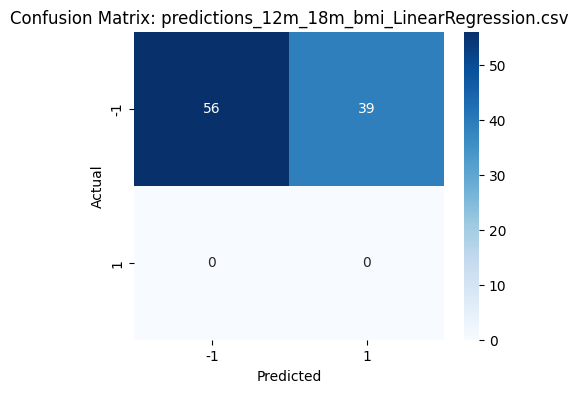

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.59      0.74        95
           1       0.00      0.00      0.00         0

    accuracy                           0.59        95
   macro avg       0.50      0.29      0.37        95
weighted avg       1.00      0.59      0.74        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,3.2857,3.2857,3.2857,0.0,-1.896261e-13,-1,-1
1,2461123462,-0.2746,-0.2746,-0.2746,0.0,-9.586776e-14,-1,-1
2,122659568,0.5150,0.5150,0.5150,0.0,-2.775558e-15,-1,-1
3,6570288555,0.6603,0.6603,0.6603,0.0,8.171241e-14,-1,1
4,6490206080,-2.3922,-2.3922,-2.3922,0.0,8.260059e-14,-1,1
5,2501036867,0.1818,0.1818,0.1818,0.0,3.216871e-14,-1,1
6,2501033558,-1.1644,-1.1644,-1.1644,0.0,-2.620126e-14,-1,-1
7,122587383,0.0663,0.0663,0.0663,0.0,3.622103e-14,-1,1
8,2501056450,-0.0733,-0.0733,-0.0733,0.0,1.385003e-14,-1,1
9,2461104591,-0.0636,-0.0636,-0.0636,0.0,2.123302e-15,-1,1



=== predictions_12m_18m_bmi_MLP.csv ===


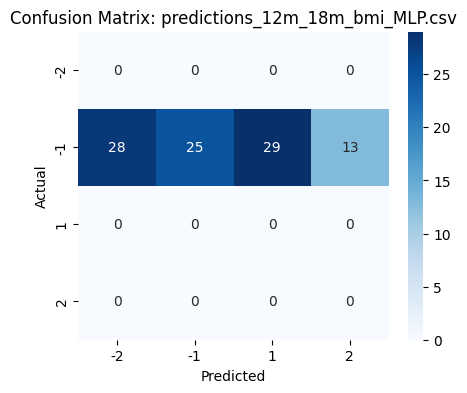

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.26      0.42        95
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.26        95
   macro avg       0.25      0.07      0.10        95
weighted avg       1.00      0.26      0.42        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,3.2857,3.2857,2.645569,0.0,-0.640131,-1,-1
1,2461123462,-0.2746,-0.2746,0.284517,0.0,0.559117,-1,1
2,122659568,0.5150,0.5150,1.126065,0.0,0.611065,-1,1
3,6570288555,0.6603,0.6603,-0.205522,0.0,-0.865822,-1,-2
4,6490206080,-2.3922,-2.3922,-3.220491,0.0,-0.828291,-1,-2
5,2501036867,0.1818,0.1818,0.545427,0.0,0.363627,-1,1
6,2501033558,-1.1644,-1.1644,-0.693375,0.0,0.471025,-1,1
7,122587383,0.0663,0.0663,-0.544436,0.0,-0.610736,-1,-1
8,2501056450,-0.0733,-0.0733,0.787770,0.0,0.861070,-1,2
9,2461104591,-0.0636,-0.0636,-0.215173,0.0,-0.151573,-1,-1



=== predictions_12m_18m_bmi_SVR.csv ===


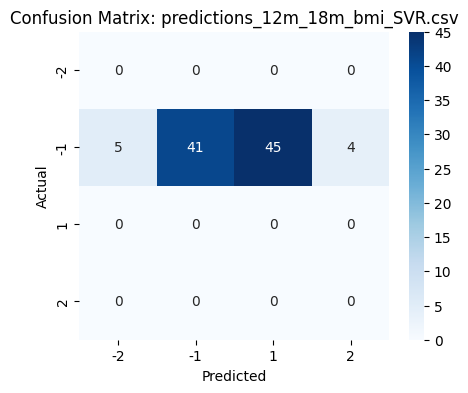

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.43      0.60        95
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.43        95
   macro avg       0.25      0.11      0.15        95
weighted avg       1.00      0.43      0.60        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,3.2857,3.2857,0.519145,0.0,-2.766555,-1,-2
1,2461123462,-0.2746,-0.2746,0.034775,0.0,0.309375,-1,1
2,122659568,0.5150,0.5150,0.733433,0.0,0.218433,-1,1
3,6570288555,0.6603,0.6603,-0.240747,0.0,-0.901047,-1,-2
4,6490206080,-2.3922,-2.3922,-2.431659,0.0,-0.039459,-1,-1
5,2501036867,0.1818,0.1818,-0.101773,0.0,-0.283573,-1,-1
6,2501033558,-1.1644,-1.1644,-0.920589,0.0,0.243811,-1,1
7,122587383,0.0663,0.0663,0.322254,0.0,0.255954,-1,1
8,2501056450,-0.0733,-0.0733,-0.473456,0.0,-0.400156,-1,-1
9,2461104591,-0.0636,-0.0636,0.085431,0.0,0.149031,-1,1



=== predictions_12m_18m_bmi_XGBoost.csv ===


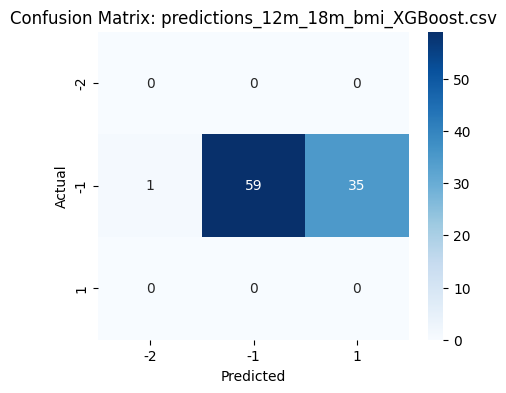

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.62      0.77        95
           1       0.00      0.00      0.00         0

    accuracy                           0.62        95
   macro avg       0.33      0.21      0.26        95
weighted avg       1.00      0.62      0.77        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,3.2857,3.2857,2.791254,0.0,-0.494445,-1,-1
1,2461123462,-0.2746,-0.2746,-0.297606,0.0,-0.023006,-1,-1
2,122659568,0.5150,0.5150,0.546062,0.0,0.031062,-1,1
3,6570288555,0.6603,0.6603,0.656319,0.0,-0.003981,-1,-1
4,6490206080,-2.3922,-2.3922,-2.413762,0.0,-0.021562,-1,-1
5,2501036867,0.1818,0.1818,0.189061,0.0,0.007261,-1,1
6,2501033558,-1.1644,-1.1644,-1.217119,0.0,-0.052719,-1,-1
7,122587383,0.0663,0.0663,0.070866,0.0,0.004566,-1,1
8,2501056450,-0.0733,-0.0733,-0.147016,0.0,-0.073716,-1,-1
9,2461104591,-0.0636,-0.0636,-0.116695,0.0,-0.053095,-1,-1



=== predictions_12m_18m_ht_LinearRegression.csv ===


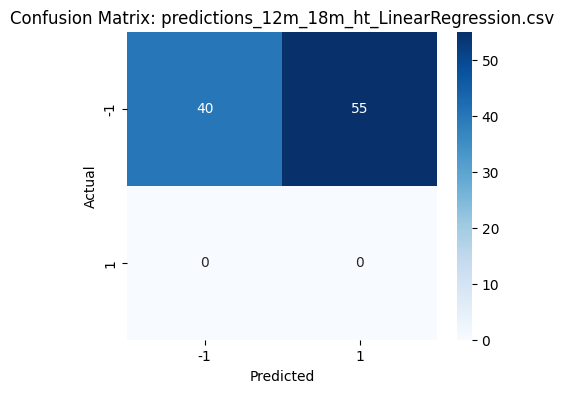

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.42      0.59        95
           1       0.00      0.00      0.00         0

    accuracy                           0.42        95
   macro avg       0.50      0.21      0.30        95
weighted avg       1.00      0.42      0.59        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,-0.555,-0.555,-5.550000e-01,0.0,2.442491e-15,-1,1
1,2461123462,-0.730,-0.730,-7.300000e-01,0.0,0.000000e+00,-1,-1
2,122659568,-0.580,-0.580,-5.800000e-01,0.0,8.881784e-16,-1,1
3,6570288555,-1.560,-1.560,-1.560000e+00,0.0,-1.998401e-15,-1,-1
4,6490206080,-0.730,-0.730,-7.300000e-01,0.0,-3.330669e-16,-1,-1
5,2501036867,0.390,0.390,3.900000e-01,0.0,-1.387779e-15,-1,-1
6,2501033558,1.550,1.550,1.550000e+00,0.0,2.664535e-15,-1,1
7,122587383,-1.150,-1.150,-1.150000e+00,0.0,1.554312e-15,-1,1
8,2501056450,0.000,0.000,-2.831069e-15,0.0,-2.831069e-15,-1,-1
9,2461104591,-1.170,-1.170,-1.170000e+00,0.0,2.220446e-15,-1,1



=== predictions_12m_18m_ht_MLP.csv ===


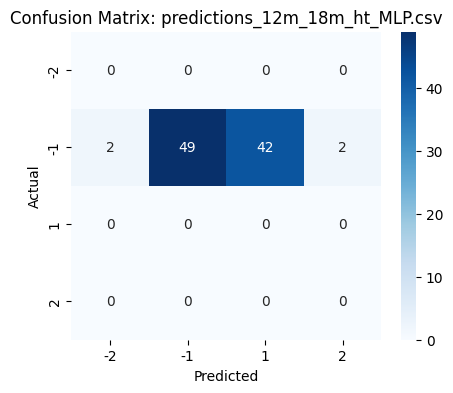

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.52      0.68        95
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.52        95
   macro avg       0.25      0.13      0.17        95
weighted avg       1.00      0.52      0.68        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,-0.555,-0.555,-0.296408,0.0,0.258592,-1,1
1,2461123462,-0.730,-0.730,-0.827788,0.0,-0.097788,-1,-1
2,122659568,-0.580,-0.580,-0.630390,0.0,-0.050390,-1,-1
3,6570288555,-1.560,-1.560,-2.250542,0.0,-0.690542,-1,-2
4,6490206080,-0.730,-0.730,-0.740065,0.0,-0.010065,-1,-1
5,2501036867,0.390,0.390,0.506089,0.0,0.116089,-1,1
6,2501033558,1.550,1.550,1.522283,0.0,-0.027717,-1,-1
7,122587383,-1.150,-1.150,-1.187574,0.0,-0.037574,-1,-1
8,2501056450,0.000,0.000,0.093284,0.0,0.093284,-1,1
9,2461104591,-1.170,-1.170,-1.185535,0.0,-0.015535,-1,-1



=== predictions_12m_18m_ht_SVR.csv ===


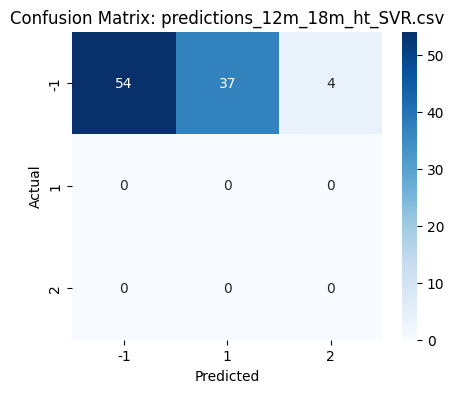

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.57      0.72        95
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.57        95
   macro avg       0.33      0.19      0.24        95
weighted avg       1.00      0.57      0.72        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,-0.555,-0.555,-0.232830,0.0,0.322170,-1,1
1,2461123462,-0.730,-0.730,-0.687975,0.0,0.042025,-1,1
2,122659568,-0.580,-0.580,-0.722142,0.0,-0.142142,-1,-1
3,6570288555,-1.560,-1.560,-0.987960,0.0,0.572040,-1,1
4,6490206080,-0.730,-0.730,-0.883340,0.0,-0.153340,-1,-1
5,2501036867,0.390,0.390,0.637685,0.0,0.247685,-1,1
6,2501033558,1.550,1.550,1.427837,0.0,-0.122163,-1,-1
7,122587383,-1.150,-1.150,-1.368187,0.0,-0.218187,-1,-1
8,2501056450,0.000,0.000,-0.130311,0.0,-0.130311,-1,-1
9,2461104591,-1.170,-1.170,-1.195488,0.0,-0.025488,-1,-1



=== predictions_12m_18m_ht_XGBoost.csv ===


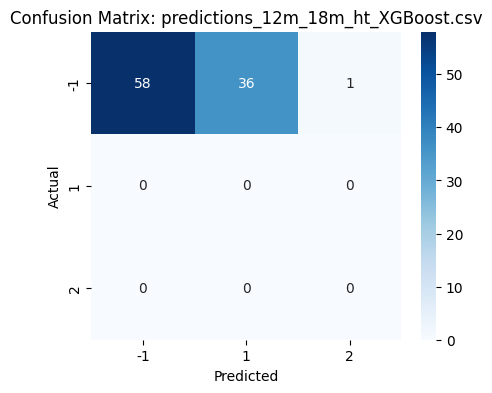

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.61      0.76        95
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.61        95
   macro avg       0.33      0.20      0.25        95
weighted avg       1.00      0.61      0.76        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,-0.555,-0.555,-0.574225,0.0,-0.019225,-1,-1
1,2461123462,-0.730,-0.730,-0.734663,0.0,-0.004663,-1,-1
2,122659568,-0.580,-0.580,-0.579998,0.0,0.000002,-1,1
3,6570288555,-1.560,-1.560,-1.561243,0.0,-0.001243,-1,-1
4,6490206080,-0.730,-0.730,-0.729698,0.0,0.000302,-1,1
5,2501036867,0.390,0.390,0.388333,0.0,-0.001667,-1,-1
6,2501033558,1.550,1.550,1.549831,0.0,-0.000169,-1,-1
7,122587383,-1.150,-1.150,-1.151663,0.0,-0.001663,-1,-1
8,2501056450,0.000,0.000,0.000361,0.0,0.000361,-1,1
9,2461104591,-1.170,-1.170,-1.168074,0.0,0.001926,-1,1



=== predictions_12m_18m_wt_LinearRegression.csv ===


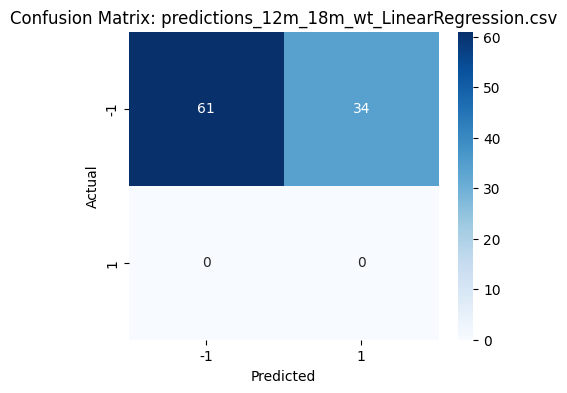

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.64      0.78        95
           1       0.00      0.00      0.00         0

    accuracy                           0.64        95
   macro avg       0.50      0.32      0.39        95
weighted avg       1.00      0.64      0.78        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,0.815,0.815,0.815,0.0,-1.110223e-15,-1,-1
1,2461123462,-0.630,-0.630,-0.630,0.0,9.992007e-16,-1,1
2,122659568,0.050,0.050,0.050,0.0,-1.179612e-15,-1,-1
3,2501045971,-2.690,-2.690,-2.690,0.0,-1.332268e-15,-1,-1
4,2501038967,-0.420,-0.420,-0.420,0.0,-4.440892e-16,-1,-1
5,2501059522,-2.220,-2.220,-2.220,0.0,-4.440892e-16,-1,-1
6,2501033558,0.050,0.050,0.050,0.0,8.187895e-16,-1,1
7,122587383,-0.630,-0.630,-0.630,0.0,-1.110223e-16,-1,-1
8,2501011104,0.330,0.330,0.330,0.0,1.498801e-15,-1,1
9,2461104591,-0.720,-0.720,-0.720,0.0,-8.881784e-16,-1,-1



=== predictions_12m_18m_wt_MLP.csv ===


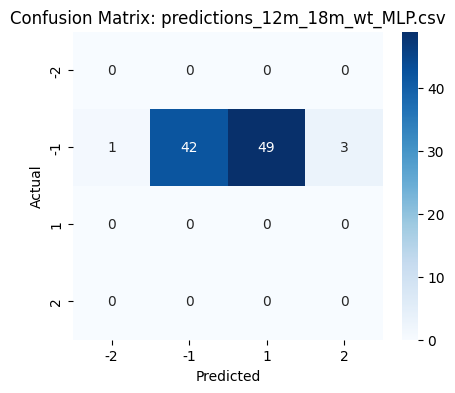

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.44      0.61        95
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.44        95
   macro avg       0.25      0.11      0.15        95
weighted avg       1.00      0.44      0.61        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,0.815,0.815,0.365732,0.0,-0.449268,-1,-1
1,2461123462,-0.630,-0.630,-0.311846,0.0,0.318154,-1,1
2,122659568,0.050,0.050,0.109935,0.0,0.059935,-1,1
3,2501045971,-2.690,-2.690,-2.436212,0.0,0.253788,-1,1
4,2501038967,-0.420,-0.420,-0.113355,0.0,0.306645,-1,1
5,2501059522,-2.220,-2.220,-2.033264,0.0,0.186736,-1,1
6,2501033558,0.050,0.050,0.106221,0.0,0.056221,-1,1
7,122587383,-0.630,-0.630,-0.640654,0.0,-0.010654,-1,-1
8,2501011104,0.330,0.330,0.546755,0.0,0.216755,-1,1
9,2461104591,-0.720,-0.720,-0.558567,0.0,0.161433,-1,1



=== predictions_12m_18m_wt_SVR.csv ===


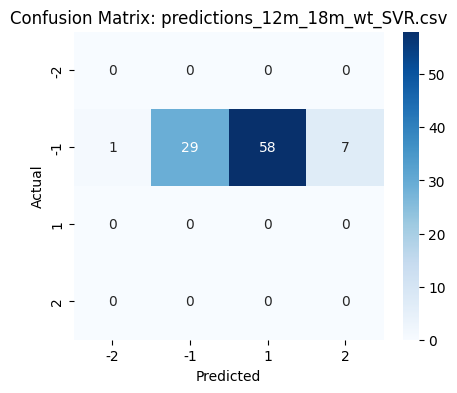

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.31      0.47        95
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.31        95
   macro avg       0.25      0.08      0.12        95
weighted avg       1.00      0.31      0.47        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,0.815,0.815,0.220105,0.0,-0.594895,-1,-1
1,2461123462,-0.630,-0.630,-0.364229,0.0,0.265771,-1,1
2,122659568,0.050,0.050,0.216560,0.0,0.166560,-1,1
3,2501045971,-2.690,-2.690,-2.716095,0.0,-0.026095,-1,-1
4,2501038967,-0.420,-0.420,-0.172859,0.0,0.247141,-1,1
5,2501059522,-2.220,-2.220,-2.074252,0.0,0.145748,-1,1
6,2501033558,0.050,0.050,0.062340,0.0,0.012340,-1,1
7,122587383,-0.630,-0.630,-0.506476,0.0,0.123524,-1,1
8,2501011104,0.330,0.330,0.474286,0.0,0.144286,-1,1
9,2461104591,-0.720,-0.720,-0.688941,0.0,0.031059,-1,1



=== predictions_12m_18m_wt_XGBoost.csv ===


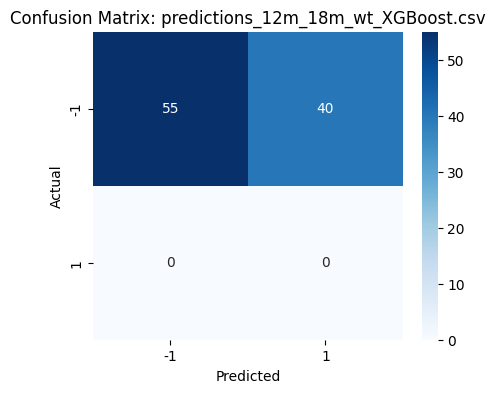

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.58      0.73        95
           1       0.00      0.00      0.00         0

    accuracy                           0.58        95
   macro avg       0.50      0.29      0.37        95
weighted avg       1.00      0.58      0.73        95


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2461062285,0.815,0.815,0.798343,0.0,-0.016657,-1,-1
1,2461123462,-0.630,-0.630,-0.630432,0.0,-0.000432,-1,-1
2,122659568,0.050,0.050,0.057352,0.0,0.007352,-1,1
3,2501045971,-2.690,-2.690,-2.695463,0.0,-0.005463,-1,-1
4,2501038967,-0.420,-0.420,-0.419585,0.0,0.000415,-1,1
5,2501059522,-2.220,-2.220,-2.208263,0.0,0.011737,-1,1
6,2501033558,0.050,0.050,0.049970,0.0,-0.000030,-1,-1
7,122587383,-0.630,-0.630,-0.629908,0.0,0.000092,-1,1
8,2501011104,0.330,0.330,0.334298,0.0,0.004298,-1,1
9,2461104591,-0.720,-0.720,-0.721052,0.0,-0.001052,-1,-1



=== predictions_18m_24m_bmi_LinearRegression.csv ===


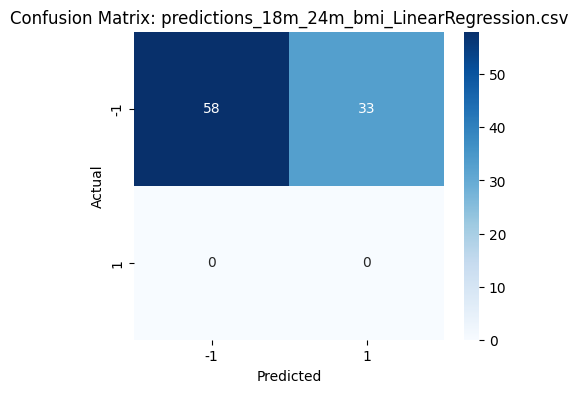

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.64      0.78        91
           1       0.00      0.00      0.00         0

    accuracy                           0.64        91
   macro avg       0.50      0.32      0.39        91
weighted avg       1.00      0.64      0.78        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501052072,-0.752400,-0.752400,-0.752400,0.0,-1.776357e-15,-1,-1
1,2289017043,-3.109300,-3.109300,-3.109300,0.0,8.881784e-16,-1,1
2,6490198509,0.013900,0.013900,0.013900,0.0,-4.638651e-15,-1,-1
3,6490206080,-2.705700,-2.705700,-2.705700,0.0,-4.440892e-16,-1,-1
4,2501020316,-0.961707,-0.961707,-0.961707,0.0,-2.109424e-15,-1,-1
5,2501044169,-1.162900,-1.162900,-1.162900,0.0,0.000000e+00,-1,-1
6,2501041682,-1.989900,-1.989900,-1.989900,0.0,1.110223e-15,-1,1
7,2501007042,1.030373,1.030373,1.030373,0.0,-3.774758e-15,-1,-1
8,6490202522,-2.815100,-2.815100,-2.815100,0.0,-4.440892e-16,-1,-1
9,122670469,3.333100,3.333100,3.333100,0.0,-1.776357e-15,-1,-1



=== predictions_18m_24m_bmi_MLP.csv ===


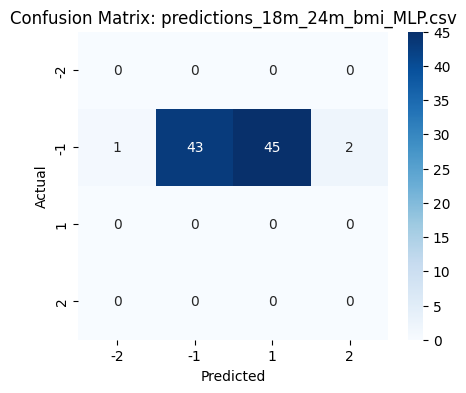

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.47      0.64        91
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.47        91
   macro avg       0.25      0.12      0.16        91
weighted avg       1.00      0.47      0.64        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501052072,-0.752400,-0.752400,-0.868135,0.0,-0.115735,-1,-1
1,2289017043,-3.109300,-3.109300,-2.671606,0.0,0.437694,-1,1
2,6490198509,0.013900,0.013900,0.423996,0.0,0.410096,-1,1
3,6490206080,-2.705700,-2.705700,-2.593676,0.0,0.112024,-1,1
4,2501020316,-0.961707,-0.961707,-1.045536,0.0,-0.083828,-1,-1
5,2501044169,-1.162900,-1.162900,-1.522868,0.0,-0.359968,-1,-1
6,2501041682,-1.989900,-1.989900,-1.747078,0.0,0.242822,-1,1
7,2501007042,1.030373,1.030373,0.736821,0.0,-0.293552,-1,-1
8,6490202522,-2.815100,-2.815100,-2.543712,0.0,0.271388,-1,1
9,122670469,3.333100,3.333100,3.020368,0.0,-0.312732,-1,-1



=== predictions_18m_24m_bmi_SVR.csv ===


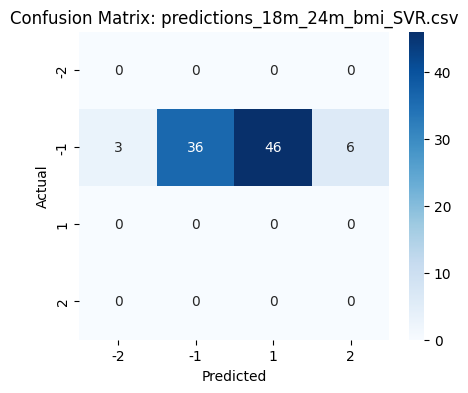

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.40      0.57        91
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.40        91
   macro avg       0.25      0.10      0.14        91
weighted avg       1.00      0.40      0.57        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501052072,-0.752400,-0.752400,-0.841472,0.0,-0.089072,-1,-1
1,2289017043,-3.109300,-3.109300,-2.043777,0.0,1.065523,-1,2
2,6490198509,0.013900,0.013900,0.137569,0.0,0.123669,-1,1
3,6490206080,-2.705700,-2.705700,-2.767265,0.0,-0.061565,-1,-1
4,2501020316,-0.961707,-0.961707,-0.922769,0.0,0.038938,-1,1
5,2501044169,-1.162900,-1.162900,-1.481132,0.0,-0.318232,-1,-1
6,2501041682,-1.989900,-1.989900,-1.836592,0.0,0.153308,-1,1
7,2501007042,1.030373,1.030373,0.912387,0.0,-0.117986,-1,-1
8,6490202522,-2.815100,-2.815100,-2.713983,0.0,0.101117,-1,1
9,122670469,3.333100,3.333100,2.224576,0.0,-1.108524,-1,-2



=== predictions_18m_24m_bmi_XGBoost.csv ===


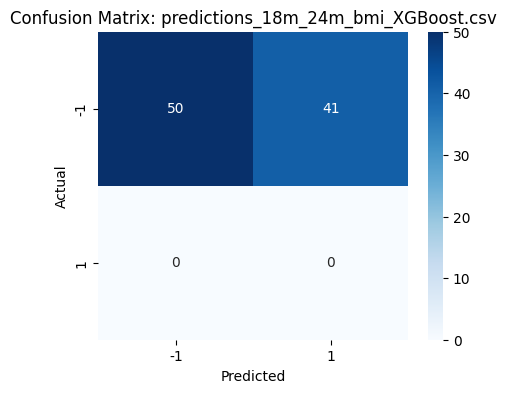

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.55      0.71        91
           1       0.00      0.00      0.00         0

    accuracy                           0.55        91
   macro avg       0.50      0.27      0.35        91
weighted avg       1.00      0.55      0.71        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501052072,-0.752400,-0.752400,-0.750042,0.0,0.002358,-1,1
1,2289017043,-3.109300,-3.109300,-3.091664,0.0,0.017636,-1,1
2,6490198509,0.013900,0.013900,0.038034,0.0,0.024134,-1,1
3,6490206080,-2.705700,-2.705700,-2.675128,0.0,0.030572,-1,1
4,2501020316,-0.961707,-0.961707,-0.964097,0.0,-0.002390,-1,-1
5,2501044169,-1.162900,-1.162900,-1.177480,0.0,-0.014580,-1,-1
6,2501041682,-1.989900,-1.989900,-2.056782,0.0,-0.066882,-1,-1
7,2501007042,1.030373,1.030373,1.008503,0.0,-0.021870,-1,-1
8,6490202522,-2.815100,-2.815100,-2.892541,0.0,-0.077441,-1,-1
9,122670469,3.333100,3.333100,2.926774,0.0,-0.406326,-1,-1



=== predictions_18m_24m_ht_LinearRegression.csv ===


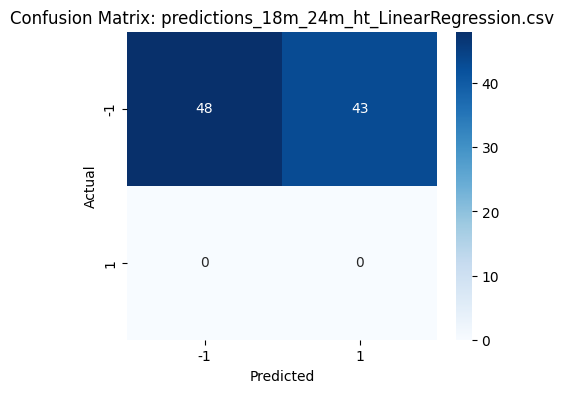

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.53      0.69        91
           1       0.00      0.00      0.00         0

    accuracy                           0.53        91
   macro avg       0.50      0.26      0.35        91
weighted avg       1.00      0.53      0.69        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501057872,1.760000,1.760000,1.760000,0.0,1.332268e-15,-1,1
1,2289251811,-0.590000,-0.590000,-0.590000,0.0,1.554312e-15,-1,1
2,2501058895,-0.930000,-0.930000,-0.930000,0.0,1.110223e-16,-1,1
3,2501058763,-0.470000,-0.470000,-0.470000,0.0,-9.436896e-16,-1,-1
4,2501020391,-4.180000,-4.180000,-4.180000,0.0,-1.776357e-15,-1,-1
5,2501038460,-0.590000,-0.590000,-0.590000,0.0,-1.110223e-16,-1,-1
6,2501052080,-1.620000,-1.620000,-1.620000,0.0,-1.332268e-15,-1,-1
7,2501007050,0.090000,0.090000,0.090000,0.0,-8.049117e-16,-1,-1
8,6490202522,0.100000,0.100000,0.100000,0.0,4.163336e-16,-1,1
9,122671621,-2.583879,-2.583879,-2.583879,0.0,0.000000e+00,-1,-1



=== predictions_18m_24m_ht_MLP.csv ===


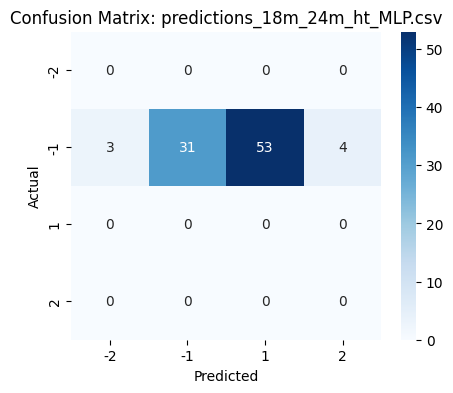

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.34      0.51        91
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.34        91
   macro avg       0.25      0.09      0.13        91
weighted avg       1.00      0.34      0.51        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501057872,1.760000,1.760000,1.383431,0.0,-0.376569,-1,-1
1,2289251811,-0.590000,-0.590000,-0.903697,0.0,-0.313697,-1,-1
2,2501058895,-0.930000,-0.930000,-0.760851,0.0,0.169149,-1,1
3,2501058763,-0.470000,-0.470000,-0.463676,0.0,0.006324,-1,1
4,2501020391,-4.180000,-4.180000,-3.641982,0.0,0.538018,-1,1
5,2501038460,-0.590000,-0.590000,-0.860996,0.0,-0.270996,-1,-1
6,2501052080,-1.620000,-1.620000,-1.498152,0.0,0.121848,-1,1
7,2501007050,0.090000,0.090000,0.226305,0.0,0.136305,-1,1
8,6490202522,0.100000,0.100000,0.509932,0.0,0.409932,-1,1
9,122671621,-2.583879,-2.583879,-1.640165,0.0,0.943714,-1,2



=== predictions_18m_24m_ht_SVR.csv ===


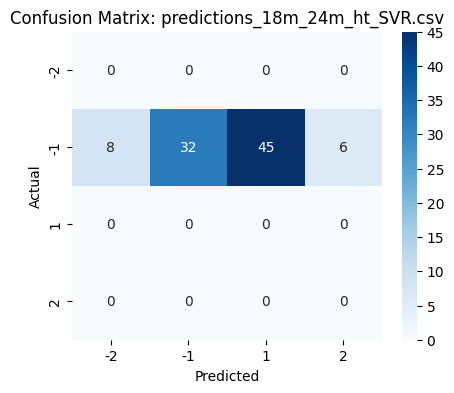

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.35      0.52        91
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.35        91
   macro avg       0.25      0.09      0.13        91
weighted avg       1.00      0.35      0.52        91


Sample rows:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.35      0.52        91
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.35        91
   macro avg       0.25      0.09      0.13        91
weighted avg       1.00      0.35      0.52        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501057872,1.760000,1.760000,0.754535,0.0,-1.005465,-1,-2
1,2289251811,-0.590000,-0.590000,-0.713042,0.0,-0.123042,-1,-1
2,2501058895,-0.930000,-0.930000,-1.030215,0.0,-0.100215,-1,-1
3,2501058763,-0.470000,-0.470000,-0.468849,0.0,0.001151,-1,1
4,2501020391,-4.180000,-4.180000,-2.800623,0.0,1.379377,-1,2
5,2501038460,-0.590000,-0.590000,-0.564466,0.0,0.025534,-1,1
6,2501052080,-1.620000,-1.620000,-1.793256,0.0,-0.173256,-1,-1
7,2501007050,0.090000,0.090000,0.265613,0.0,0.175613,-1,1
8,6490202522,0.100000,0.100000,-0.022441,0.0,-0.122441,-1,-1
9,122671621,-2.583879,-2.583879,-1.709099,0.0,0.874780,-1,2



=== predictions_18m_24m_ht_XGBoost.csv ===


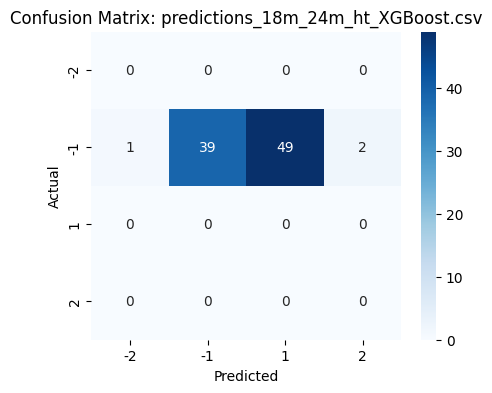

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.43      0.60        91
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.43        91
   macro avg       0.25      0.11      0.15        91
weighted avg       1.00      0.43      0.60        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501057872,1.760000,1.760000,1.826262,0.0,0.066262,-1,1
1,2289251811,-0.590000,-0.590000,-0.590870,0.0,-0.000870,-1,-1
2,2501058895,-0.930000,-0.930000,-0.929285,0.0,0.000715,-1,1
3,2501058763,-0.470000,-0.470000,-0.471863,0.0,-0.001863,-1,-1
4,2501020391,-4.180000,-4.180000,-3.424472,0.0,0.755528,-1,2
5,2501038460,-0.590000,-0.590000,-0.591638,0.0,-0.001638,-1,-1
6,2501052080,-1.620000,-1.620000,-1.617249,0.0,0.002751,-1,1
7,2501007050,0.090000,0.090000,0.092122,0.0,0.002122,-1,1
8,6490202522,0.100000,0.100000,0.099494,0.0,-0.000506,-1,-1
9,122671621,-2.583879,-2.583879,-1.558317,0.0,1.025562,-1,2



=== predictions_18m_24m_wt_LinearRegression.csv ===


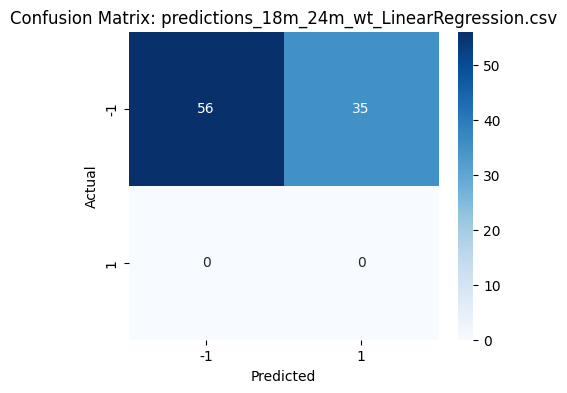

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.62      0.76        91
           1       0.00      0.00      0.00         0

    accuracy                           0.62        91
   macro avg       0.50      0.31      0.38        91
weighted avg       1.00      0.62      0.76        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501057872,1.410000,1.410000,1.410000,0.0,-6.661338e-16,-1,-1
1,2289251811,-0.610000,-0.610000,-0.610000,0.0,-1.110223e-16,-1,-1
2,2501058895,-0.610000,-0.610000,-0.610000,0.0,-5.551115e-16,-1,-1
3,2501058763,-0.630000,-0.630000,-0.630000,0.0,-4.440892e-16,-1,-1
4,2501020391,-2.800000,-2.800000,-2.800000,0.0,-3.108624e-15,-1,-1
5,2501038460,-0.030000,-0.030000,-0.030000,0.0,-2.775558e-17,-1,-1
6,2501052072,0.050000,0.050000,0.050000,0.0,-9.575674e-16,-1,-1
7,2501007050,0.980000,0.980000,0.980000,0.0,-5.551115e-16,-1,-1
8,6490202522,-1.850000,-1.850000,-1.850000,0.0,8.881784e-16,-1,1
9,122671621,-3.239414,-3.239414,-3.239414,0.0,-8.881784e-16,-1,-1



=== predictions_18m_24m_wt_MLP.csv ===


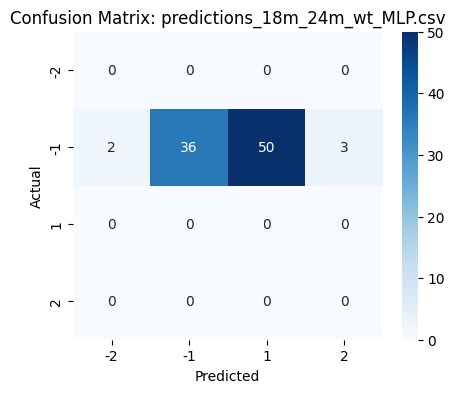

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.40      0.57        91
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.40        91
   macro avg       0.25      0.10      0.14        91
weighted avg       1.00      0.40      0.57        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501057872,1.410000,1.410000,1.186183,0.0,-0.223817,-1,-1
1,2289251811,-0.610000,-0.610000,-0.800153,0.0,-0.190153,-1,-1
2,2501058895,-0.610000,-0.610000,-0.633040,0.0,-0.023040,-1,-1
3,2501058763,-0.630000,-0.630000,-0.599762,0.0,0.030238,-1,1
4,2501020391,-2.800000,-2.800000,-2.390852,0.0,0.409148,-1,1
5,2501038460,-0.030000,-0.030000,-0.318601,0.0,-0.288601,-1,-1
6,2501052072,0.050000,0.050000,0.130286,0.0,0.080286,-1,1
7,2501007050,0.980000,0.980000,0.909027,0.0,-0.070973,-1,-1
8,6490202522,-1.850000,-1.850000,-1.441299,0.0,0.408701,-1,1
9,122671621,-3.239414,-3.239414,-2.044277,0.0,1.195137,-1,2



=== predictions_18m_24m_wt_SVR.csv ===


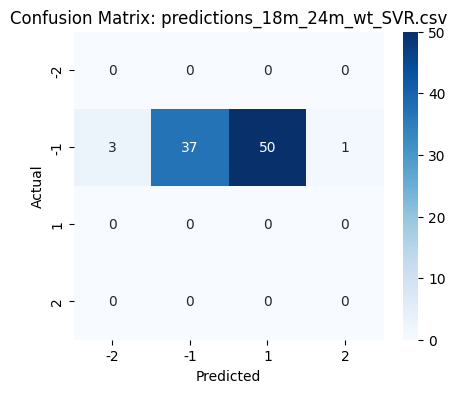

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.41      0.58        91
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.41        91
   macro avg       0.25      0.10      0.14        91
weighted avg       1.00      0.41      0.58        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501057872,1.410000,1.410000,0.765690,0.0,-0.644310,-1,-1
1,2289251811,-0.610000,-0.610000,-0.572797,0.0,0.037203,-1,1
2,2501058895,-0.610000,-0.610000,-0.681134,0.0,-0.071134,-1,-1
3,2501058763,-0.630000,-0.630000,-0.547743,0.0,0.082257,-1,1
4,2501020391,-2.800000,-2.800000,-2.188404,0.0,0.611596,-1,1
5,2501038460,-0.030000,-0.030000,0.114940,0.0,0.144940,-1,1
6,2501052072,0.050000,0.050000,0.166008,0.0,0.116008,-1,1
7,2501007050,0.980000,0.980000,1.107122,0.0,0.127122,-1,1
8,6490202522,-1.850000,-1.850000,-1.881785,0.0,-0.031785,-1,-1
9,122671621,-3.239414,-3.239414,-1.979170,0.0,1.260244,-1,2



=== predictions_18m_24m_wt_XGBoost.csv ===


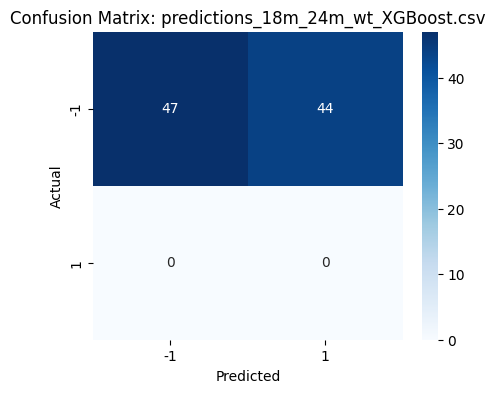

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.52      0.68        91
           1       0.00      0.00      0.00         0

    accuracy                           0.52        91
   macro avg       0.50      0.26      0.34        91
weighted avg       1.00      0.52      0.68        91


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501057872,1.410000,1.410000,1.296522,0.0,-0.113478,-1,-1
1,2289251811,-0.610000,-0.610000,-0.610279,0.0,-0.000279,-1,-1
2,2501058895,-0.610000,-0.610000,-0.610753,0.0,-0.000753,-1,-1
3,2501058763,-0.630000,-0.630000,-0.630129,0.0,-0.000129,-1,-1
4,2501020391,-2.800000,-2.800000,-2.819905,0.0,-0.019905,-1,-1
5,2501038460,-0.030000,-0.030000,-0.029428,0.0,0.000572,-1,1
6,2501052072,0.050000,0.050000,0.040314,0.0,-0.009686,-1,-1
7,2501007050,0.980000,0.980000,0.928658,0.0,-0.051342,-1,-1
8,6490202522,-1.850000,-1.850000,-1.907118,0.0,-0.057117,-1,-1
9,122671621,-3.239414,-3.239414,-2.939433,0.0,0.299981,-1,1



=== predictions_24m_36m_bmi_LinearRegression.csv ===


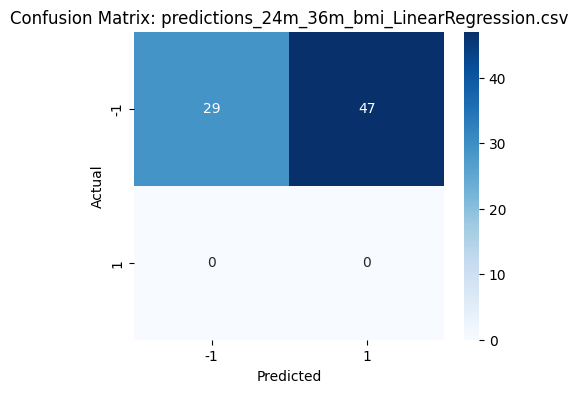

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.38      0.55        76
           1       0.00      0.00      0.00         0

    accuracy                           0.38        76
   macro avg       0.50      0.19      0.28        76
weighted avg       1.00      0.38      0.55        76


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501056051,-3.706209,-3.706209,-3.706209,0.0,-1.021405e-14,-1,-1
1,2501052196,-0.557747,-0.557747,-0.557747,0.0,1.110223e-15,-1,1
2,2501052595,-2.566046,-2.566046,-2.566046,0.0,-2.220446e-15,-1,-1
3,2501023889,-0.728739,-0.728739,-0.728739,0.0,2.109424e-15,-1,1
4,2461124371,-0.876854,-0.876854,-0.876854,0.0,-5.884182e-15,-1,-1
5,2501009835,-0.926000,-0.926000,-0.926000,0.0,8.326673e-15,-1,1
6,6560212033,-4.131212,-4.131212,-4.131212,0.0,8.881784e-16,-1,1
7,2501007042,-0.635099,-0.635099,-0.635099,0.0,2.886580e-15,-1,1
8,6710115496,-3.167980,-3.167980,-3.167980,0.0,4.440892e-16,-1,1
9,2501025849,-1.416591,-1.416591,-1.416591,0.0,4.218847e-15,-1,1



=== predictions_24m_36m_bmi_MLP.csv ===


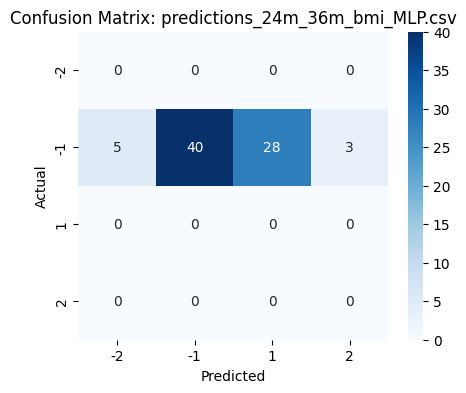

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.53      0.69        76
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.53        76
   macro avg       0.25      0.13      0.17        76
weighted avg       1.00      0.53      0.69        76


Sample rows:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.53      0.69        76
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.53        76
   macro avg       0.25      0.13      0.17        76
weighted avg       1.00      0.53      0.69        76


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501056051,-3.706209,-3.706209,-5.487772,0.0,-1.781563,-1,-2
1,2501052196,-0.557747,-0.557747,-0.377477,0.0,0.180270,-1,1
2,2501052595,-2.566046,-2.566046,-2.354435,0.0,0.211611,-1,1
3,2501023889,-0.728739,-0.728739,-0.152075,0.0,0.576664,-1,1
4,2461124371,-0.876854,-0.876854,-1.012361,0.0,-0.135507,-1,-1
5,2501009835,-0.926000,-0.926000,-1.095870,0.0,-0.169869,-1,-1
6,6560212033,-4.131212,-4.131212,-4.749578,0.0,-0.618366,-1,-1
7,2501007042,-0.635099,-0.635099,-0.866960,0.0,-0.231861,-1,-1
8,6710115496,-3.167980,-3.167980,-3.455448,0.0,-0.287467,-1,-1
9,2501025849,-1.416591,-1.416591,-1.547469,0.0,-0.130878,-1,-1



=== predictions_24m_36m_bmi_SVR.csv ===


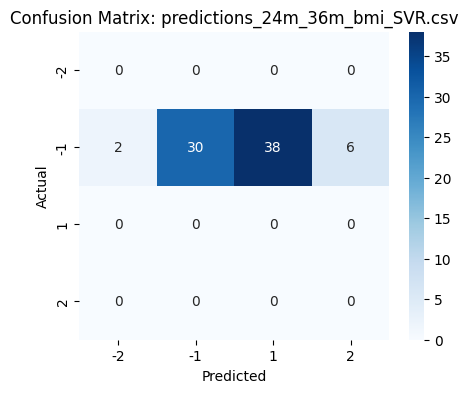

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.39      0.57        76
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.39        76
   macro avg       0.25      0.10      0.14        76
weighted avg       1.00      0.39      0.57        76


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501056051,-3.706209,-3.706209,-1.915685,0.0,1.790524,-1,2
1,2501052196,-0.557747,-0.557747,-0.548575,0.0,0.009172,-1,1
2,2501052595,-2.566046,-2.566046,-3.122239,0.0,-0.556193,-1,-1
3,2501023889,-0.728739,-0.728739,-0.499219,0.0,0.229520,-1,1
4,2461124371,-0.876854,-0.876854,-1.347096,0.0,-0.470242,-1,-1
5,2501009835,-0.926000,-0.926000,-1.002675,0.0,-0.076675,-1,-1
6,6560212033,-4.131212,-4.131212,-3.738752,0.0,0.392460,-1,1
7,2501007042,-0.635099,-0.635099,-0.795541,0.0,-0.160442,-1,-1
8,6710115496,-3.167980,-3.167980,-2.171090,0.0,0.996890,-1,2
9,2501025849,-1.416591,-1.416591,-1.403604,0.0,0.012987,-1,1



=== predictions_24m_36m_bmi_XGBoost.csv ===


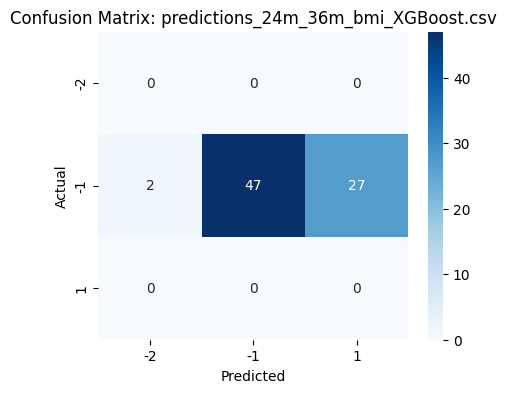

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.62      0.76        76
           1       0.00      0.00      0.00         0

    accuracy                           0.62        76
   macro avg       0.33      0.21      0.25        76
weighted avg       1.00      0.62      0.76        76


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501056051,-3.706209,-3.706209,-3.696498,0.0,0.009711,-1,1
1,2501052196,-0.557747,-0.557747,-0.541967,0.0,0.015780,-1,1
2,2501052595,-2.566046,-2.566046,-2.597093,0.0,-0.031048,-1,-1
3,2501023889,-0.728739,-0.728739,-0.734413,0.0,-0.005673,-1,-1
4,2461124371,-0.876854,-0.876854,-0.886489,0.0,-0.009635,-1,-1
5,2501009835,-0.926000,-0.926000,-0.943098,0.0,-0.017098,-1,-1
6,6560212033,-4.131212,-4.131212,-4.202139,0.0,-0.070926,-1,-1
7,2501007042,-0.635099,-0.635099,-0.606103,0.0,0.028996,-1,1
8,6710115496,-3.167980,-3.167980,-3.077791,0.0,0.090189,-1,1
9,2501025849,-1.416591,-1.416591,-1.448037,0.0,-0.031445,-1,-1



=== predictions_24m_36m_ht_LinearRegression.csv ===


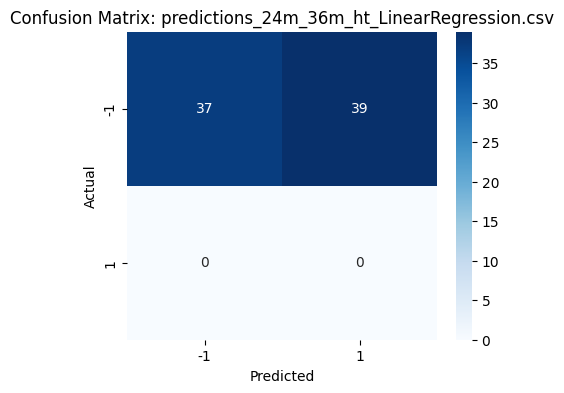

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.49      0.65        76
           1       0.00      0.00      0.00         0

    accuracy                           0.49        76
   macro avg       0.50      0.24      0.33        76
weighted avg       1.00      0.49      0.65        76


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501056541,0.894542,0.894542,0.894542,0.0,-7.771561e-16,-1,-1
1,6710114627,-0.943978,-0.943978,-0.943978,0.0,-1.776357e-15,-1,-1
2,2501052595,-0.245546,-0.245546,-0.245546,0.0,-1.443290e-15,-1,-1
3,2501028139,0.324451,0.324451,0.324451,0.0,1.271205e-14,-1,1
4,2501024192,-0.113853,-0.113853,-0.113853,0.0,-7.507883e-15,-1,-1
5,2501009126,0.172754,0.172754,0.172754,0.0,2.886580e-15,-1,1
6,2501021304,-1.526856,-1.526856,-1.526856,0.0,6.661338e-16,-1,1
7,2500997812,1.320873,1.320873,1.320873,0.0,2.886580e-15,-1,1
8,2501005457,-1.954955,-1.954955,-1.954955,0.0,1.554312e-15,-1,1
9,6710115496,2.307752,2.307752,2.307752,0.0,-5.329071e-15,-1,-1



=== predictions_24m_36m_ht_MLP.csv ===


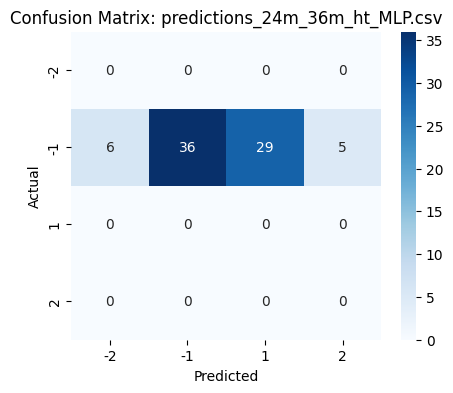

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.47      0.64        76
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.47        76
   macro avg       0.25      0.12      0.16        76
weighted avg       1.00      0.47      0.64        76


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501056541,0.894542,0.894542,0.906386,0.0,0.011844,-1,1
1,6710114627,-0.943978,-0.943978,-0.911099,0.0,0.032879,-1,1
2,2501052595,-0.245546,-0.245546,-0.186536,0.0,0.059010,-1,1
3,2501028139,0.324451,0.324451,0.162230,0.0,-0.162221,-1,-1
4,2501024192,-0.113853,-0.113853,-0.999978,0.0,-0.886124,-1,-2
5,2501009126,0.172754,0.172754,0.238872,0.0,0.066118,-1,1
6,2501021304,-1.526856,-1.526856,-0.595973,0.0,0.930883,-1,2
7,2500997812,1.320873,1.320873,1.322025,0.0,0.001152,-1,1
8,2501005457,-1.954955,-1.954955,-1.997706,0.0,-0.042751,-1,-1
9,6710115496,2.307752,2.307752,0.946172,0.0,-1.361580,-1,-2



=== predictions_24m_36m_ht_SVR.csv ===


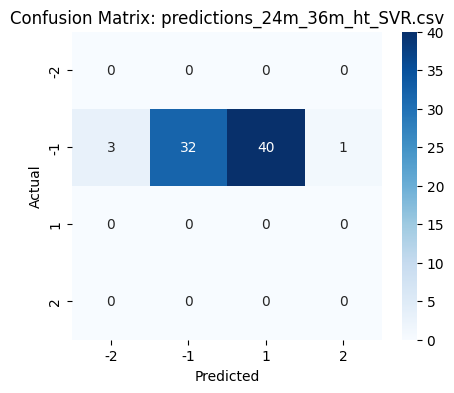

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.42      0.59        76
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.42        76
   macro avg       0.25      0.11      0.15        76
weighted avg       1.00      0.42      0.59        76


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501056541,0.894542,0.894542,0.311746,0.0,-0.582796,-1,-1
1,6710114627,-0.943978,-0.943978,-0.520459,0.0,0.423519,-1,1
2,2501052595,-0.245546,-0.245546,-0.176632,0.0,0.068914,-1,1
3,2501028139,0.324451,0.324451,-0.713486,0.0,-1.037937,-1,-2
4,2501024192,-0.113853,-0.113853,-0.696649,0.0,-0.582795,-1,-1
5,2501009126,0.172754,0.172754,0.277596,0.0,0.104842,-1,1
6,2501021304,-1.526856,-1.526856,-0.830261,0.0,0.696595,-1,2
7,2500997812,1.320873,1.320873,1.277948,0.0,-0.042925,-1,-1
8,2501005457,-1.954955,-1.954955,-1.923442,0.0,0.031513,-1,1
9,6710115496,2.307752,2.307752,0.450042,0.0,-1.857709,-1,-2



=== predictions_24m_36m_ht_XGBoost.csv ===


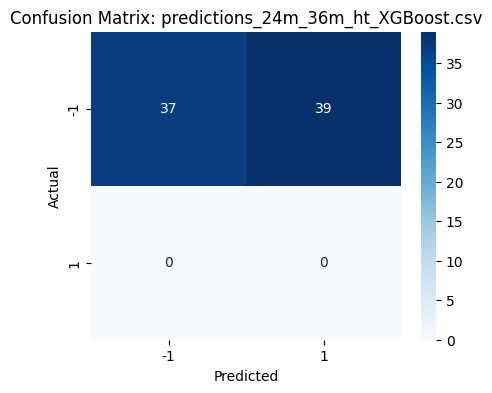

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.49      0.65        76
           1       0.00      0.00      0.00         0

    accuracy                           0.49        76
   macro avg       0.50      0.24      0.33        76
weighted avg       1.00      0.49      0.65        76


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501056541,0.894542,0.894542,0.896779,0.0,0.002237,-1,1
1,6710114627,-0.943978,-0.943978,-0.916660,0.0,0.027318,-1,1
2,2501052595,-0.245546,-0.245546,-0.246321,0.0,-0.000775,-1,-1
3,2501028139,0.324451,0.324451,0.324813,0.0,0.000361,-1,1
4,2501024192,-0.113853,-0.113853,-0.113037,0.0,0.000816,-1,1
5,2501009126,0.172754,0.172754,0.172106,0.0,-0.000648,-1,-1
6,2501021304,-1.526856,-1.526856,-1.520788,0.0,0.006068,-1,1
7,2500997812,1.320873,1.320873,1.301495,0.0,-0.019379,-1,-1
8,2501005457,-1.954955,-1.954955,-1.957109,0.0,-0.002154,-1,-1
9,6710115496,2.307752,2.307752,2.124281,0.0,-0.183470,-1,-1



=== predictions_24m_36m_wt_LinearRegression.csv ===


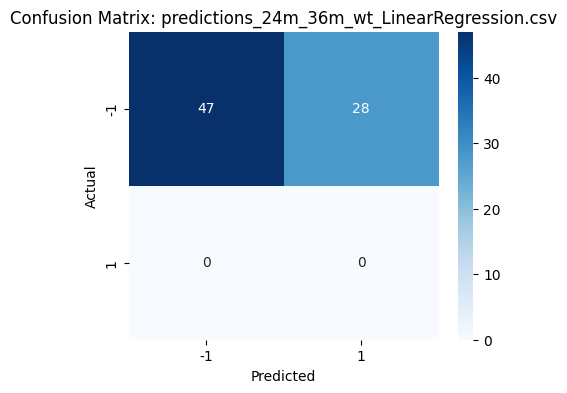

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.63      0.77        75
           1       0.00      0.00      0.00         0

    accuracy                           0.63        75
   macro avg       0.50      0.31      0.39        75
weighted avg       1.00      0.63      0.77        75


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490203601,-3.110103,-3.110103,-3.110103,0.0,2.220446e-15,-1,1
1,2461053014,-2.620446,-2.620446,-2.620446,0.0,4.440892e-16,-1,1
2,122635096,-0.103930,-0.103930,-0.103930,0.0,-1.276756e-15,-1,-1
3,6490195453,-2.733713,-2.733713,-2.733713,0.0,-4.440892e-16,-1,-1
4,2500999300,-2.320618,-2.320618,-2.320618,0.0,-8.881784e-16,-1,-1
5,2501049421,-0.143072,-0.143072,-0.143072,0.0,7.216450e-16,-1,1
6,2501005554,-3.110103,-3.110103,-3.110103,0.0,-4.440892e-16,-1,-1
7,2501018095,-1.826846,-1.826846,-1.826846,0.0,6.661338e-16,-1,1
8,6490187851,0.272347,0.272347,0.272347,0.0,-3.330669e-16,-1,-1
9,2501020391,-3.793416,-3.793416,-3.793416,0.0,2.220446e-15,-1,1



=== predictions_24m_36m_wt_MLP.csv ===


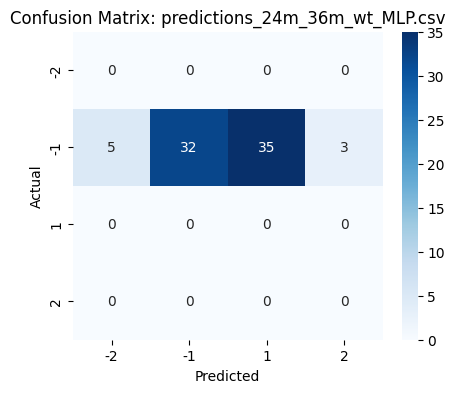

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.43      0.60        75
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.43        75
   macro avg       0.25      0.11      0.15        75
weighted avg       1.00      0.43      0.60        75


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490203601,-3.110103,-3.110103,-3.085303,0.0,0.024800,-1,1
1,2461053014,-2.620446,-2.620446,-2.057338,0.0,0.563109,-1,1
2,122635096,-0.103930,-0.103930,0.147346,0.0,0.251276,-1,1
3,6490195453,-2.733713,-2.733713,-2.398026,0.0,0.335687,-1,1
4,2500999300,-2.320618,-2.320618,-1.900674,0.0,0.419944,-1,1
5,2501049421,-0.143072,-0.143072,-0.269169,0.0,-0.126098,-1,-1
6,2501005554,-3.110103,-3.110103,-3.165811,0.0,-0.055708,-1,-1
7,2501018095,-1.826846,-1.826846,-1.597673,0.0,0.229173,-1,1
8,6490187851,0.272347,0.272347,0.363230,0.0,0.090883,-1,1
9,2501020391,-3.793416,-3.793416,-2.401766,0.0,1.391650,-1,2



=== predictions_24m_36m_wt_SVR.csv ===


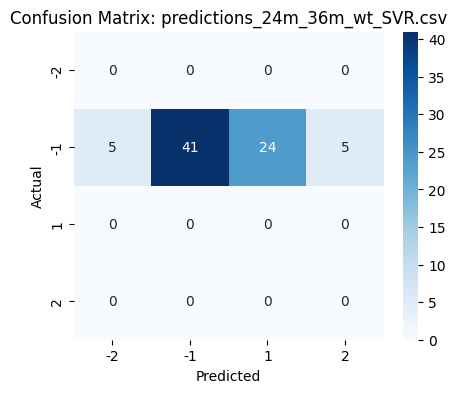

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.55      0.71        75
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.55        75
   macro avg       0.25      0.14      0.18        75
weighted avg       1.00      0.55      0.71        75


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490203601,-3.110103,-3.110103,-3.142351,0.0,-0.032248,-1,-1
1,2461053014,-2.620446,-2.620446,-2.752935,0.0,-0.132488,-1,-1
2,122635096,-0.103930,-0.103930,-0.158469,0.0,-0.054539,-1,-1
3,6490195453,-2.733713,-2.733713,-2.979611,0.0,-0.245898,-1,-1
4,2500999300,-2.320618,-2.320618,-2.435730,0.0,-0.115113,-1,-1
5,2501049421,-0.143072,-0.143072,-0.298998,0.0,-0.155926,-1,-1
6,2501005554,-3.110103,-3.110103,-2.919467,0.0,0.190636,-1,1
7,2501018095,-1.826846,-1.826846,-1.862057,0.0,-0.035212,-1,-1
8,6490187851,0.272347,0.272347,0.268452,0.0,-0.003895,-1,-1
9,2501020391,-3.793416,-3.793416,-2.575049,0.0,1.218367,-1,2



=== predictions_24m_36m_wt_XGBoost.csv ===


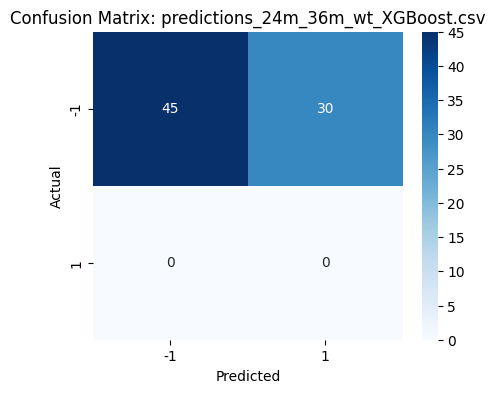

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.60      0.75        75
           1       0.00      0.00      0.00         0

    accuracy                           0.60        75
   macro avg       0.50      0.30      0.37        75
weighted avg       1.00      0.60      0.75        75


Sample rows:
              precision    recall  f1-score   support

          -1       1.00      0.60      0.75        75
           1       0.00      0.00      0.00         0

    accuracy                           0.60        75
   macro avg       0.50      0.30      0.37        75
weighted avg       1.00      0.60      0.75        75


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490203601,-3.110103,-3.110103,-3.125367,0.0,-0.015264,-1,-1
1,2461053014,-2.620446,-2.620446,-2.361892,0.0,0.258555,-1,1
2,122635096,-0.103930,-0.103930,-0.108551,0.0,-0.004621,-1,-1
3,6490195453,-2.733713,-2.733713,-2.770859,0.0,-0.037146,-1,-1
4,2500999300,-2.320618,-2.320618,-2.377443,0.0,-0.056825,-1,-1
5,2501049421,-0.143072,-0.143072,-0.233781,0.0,-0.090709,-1,-1
6,2501005554,-3.110103,-3.110103,-3.121256,0.0,-0.011153,-1,-1
7,2501018095,-1.826846,-1.826846,-1.828329,0.0,-0.001483,-1,-1
8,6490187851,0.272347,0.272347,0.233761,0.0,-0.038586,-1,-1
9,2501020391,-3.793416,-3.793416,-3.604673,0.0,0.188743,-1,1



=== predictions_36m_48m_bmi_LinearRegression.csv ===


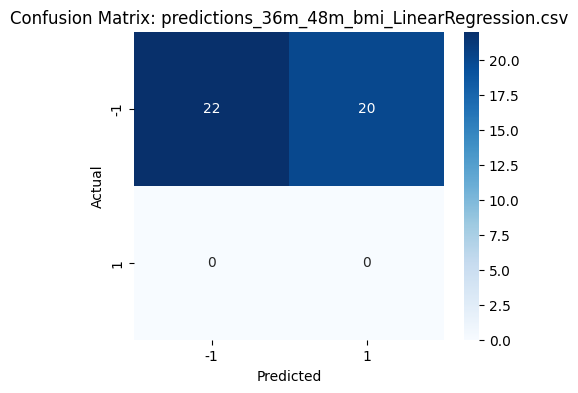

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.52      0.69        42
           1       0.00      0.00      0.00         0

    accuracy                           0.52        42
   macro avg       0.50      0.26      0.34        42
weighted avg       1.00      0.52      0.69        42


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490188651,-2.542294,-2.542294,-2.542294,0.0,1.110223e-14,-1,1
1,2461063052,-3.403648,-3.403648,-3.403648,0.0,7.105427e-15,-1,1
2,2501013905,-1.935505,-1.935505,-1.935505,0.0,4.440892e-15,-1,1
3,2501020391,-0.332350,-0.332350,-0.332350,0.0,1.554312e-14,-1,1
4,6490192950,-0.608224,-0.608224,-0.608224,0.0,-6.106227e-15,-1,-1
5,2461051534,-2.386035,-2.386035,-2.386035,0.0,5.329071e-15,-1,1
6,2501022394,-1.863603,-1.863603,-1.863603,0.0,-7.549517e-15,-1,-1
7,2501036077,-0.884639,-0.884639,-0.884639,0.0,-1.110223e-14,-1,-1
8,2461074811,-3.038275,-3.038275,-3.038275,0.0,-3.108624e-15,-1,-1
9,2501039408,-0.721514,-0.721514,-0.721514,0.0,-9.436896e-15,-1,-1



=== predictions_36m_48m_bmi_MLP.csv ===


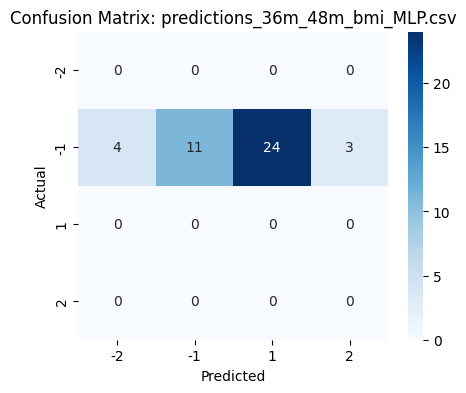

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.26      0.42        42
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.26        42
   macro avg       0.25      0.07      0.10        42
weighted avg       1.00      0.26      0.42        42


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490188651,-2.542294,-2.542294,-1.412676,0.0,1.129617,-1,2
1,2461063052,-3.403648,-3.403648,-2.192898,0.0,1.210751,-1,2
2,2501013905,-1.935505,-1.935505,-1.397679,0.0,0.537826,-1,1
3,2501020391,-0.332350,-0.332350,-0.616920,0.0,-0.284570,-1,-1
4,6490192950,-0.608224,-0.608224,-0.716566,0.0,-0.108341,-1,-1
5,2461051534,-2.386035,-2.386035,-1.870947,0.0,0.515088,-1,1
6,2501022394,-1.863603,-1.863603,-1.417501,0.0,0.446102,-1,1
7,2501036077,-0.884639,-0.884639,-0.692869,0.0,0.191770,-1,1
8,2461074811,-3.038275,-3.038275,-2.891807,0.0,0.146468,-1,1
9,2501039408,-0.721514,-0.721514,-0.338078,0.0,0.383436,-1,1



=== predictions_36m_48m_bmi_SVR.csv ===


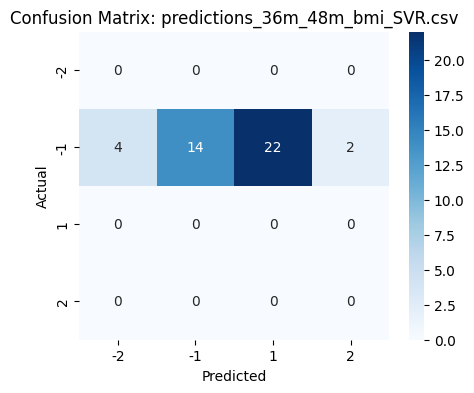

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.33      0.50        42
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.33        42
   macro avg       0.25      0.08      0.12        42
weighted avg       1.00      0.33      0.50        42


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490188651,-2.542294,-2.542294,-2.775109,0.0,-0.232815,-1,-1
1,2461063052,-3.403648,-3.403648,-3.282998,0.0,0.120651,-1,1
2,2501013905,-1.935505,-1.935505,-1.812981,0.0,0.122524,-1,1
3,2501020391,-0.332350,-0.332350,-1.490209,0.0,-1.157859,-1,-2
4,6490192950,-0.608224,-0.608224,-1.032519,0.0,-0.424294,-1,-1
5,2461051534,-2.386035,-2.386035,-2.096397,0.0,0.289638,-1,1
6,2501022394,-1.863603,-1.863603,-1.605831,0.0,0.257773,-1,1
7,2501036077,-0.884639,-0.884639,-0.946005,0.0,-0.061366,-1,-1
8,2461074811,-3.038275,-3.038275,-2.749590,0.0,0.288685,-1,1
9,2501039408,-0.721514,-0.721514,-0.500578,0.0,0.220935,-1,1



=== predictions_36m_48m_bmi_XGBoost.csv ===


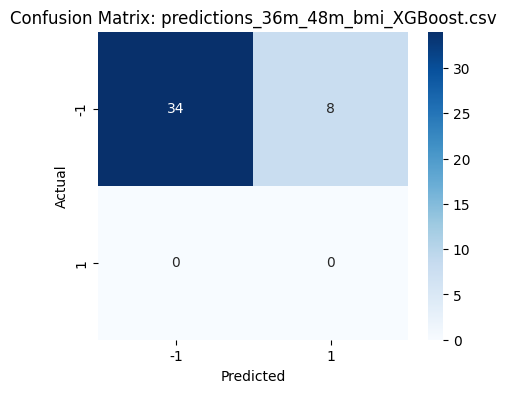

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.81      0.89        42
           1       0.00      0.00      0.00         0

    accuracy                           0.81        42
   macro avg       0.50      0.40      0.45        42
weighted avg       1.00      0.81      0.89        42


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490188651,-2.542294,-2.542294,-2.543173,0.0,-0.000880,-1,-1
1,2461063052,-3.403648,-3.403648,-3.409946,0.0,-0.006297,-1,-1
2,2501013905,-1.935505,-1.935505,-1.983629,0.0,-0.048124,-1,-1
3,2501020391,-0.332350,-0.332350,-0.323115,0.0,0.009235,-1,1
4,6490192950,-0.608224,-0.608224,-0.695531,0.0,-0.087306,-1,-1
5,2461051534,-2.386035,-2.386035,-2.388556,0.0,-0.002521,-1,-1
6,2501022394,-1.863603,-1.863603,-1.935247,0.0,-0.071643,-1,-1
7,2501036077,-0.884639,-0.884639,-0.858114,0.0,0.026525,-1,1
8,2461074811,-3.038275,-3.038275,-3.151035,0.0,-0.112760,-1,-1
9,2501039408,-0.721514,-0.721514,-0.739724,0.0,-0.018210,-1,-1



=== predictions_36m_48m_ht_LinearRegression.csv ===


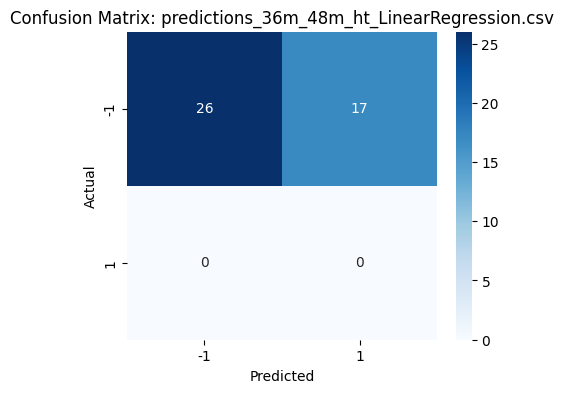

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.60      0.75        43
           1       0.00      0.00      0.00         0

    accuracy                           0.60        43
   macro avg       0.50      0.30      0.38        43
weighted avg       1.00      0.60      0.75        43


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2500997812,1.318770,1.318770,1.318770,0.0,4.218847e-15,-1,1
1,6490194309,-1.420569,-1.420569,-1.420569,0.0,-6.217249e-15,-1,-1
2,2501036077,-0.053925,-0.053925,-0.053925,0.0,7.577272e-15,-1,1
3,2501013001,-0.818186,-0.818186,-0.818186,0.0,-3.885781e-15,-1,-1
4,2501007379,-0.053925,-0.053925,-0.053925,0.0,5.828671e-16,-1,1
5,2501034244,-3.183134,-3.183134,-3.183134,0.0,-9.325873e-15,-1,-1
6,2501003128,0.449389,0.449389,0.449389,0.0,0.000000e+00,-1,-1
7,6560209253,-0.598694,-0.598694,-0.598694,0.0,3.330669e-16,-1,1
8,2289112984,-0.307421,-0.307421,-0.307421,0.0,3.053113e-15,-1,1
9,2501020316,-0.053925,-0.053925,-0.053925,0.0,-2.692291e-15,-1,-1



=== predictions_36m_48m_ht_MLP.csv ===


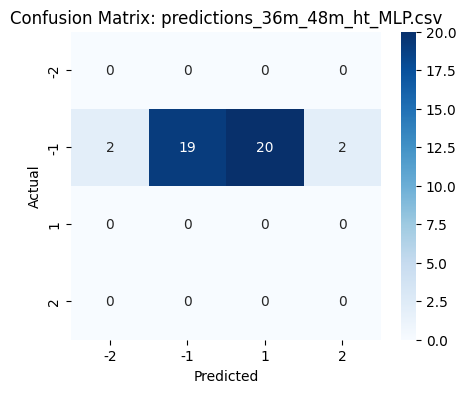

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.44      0.61        43
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.44        43
   macro avg       0.25      0.11      0.15        43
weighted avg       1.00      0.44      0.61        43


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2500997812,1.318770,1.318770,1.241015,0.0,-0.077755,-1,-1
1,6490194309,-1.420569,-1.420569,-1.098769,0.0,0.321800,-1,1
2,2501036077,-0.053925,-0.053925,0.019894,0.0,0.073819,-1,1
3,2501013001,-0.818186,-0.818186,-0.955672,0.0,-0.137485,-1,-1
4,2501007379,-0.053925,-0.053925,0.285573,0.0,0.339498,-1,1
5,2501034244,-3.183134,-3.183134,-2.634551,0.0,0.548583,-1,1
6,2501003128,0.449389,0.449389,-0.360980,0.0,-0.810368,-1,-2
7,6560209253,-0.598694,-0.598694,-0.689307,0.0,-0.090613,-1,-1
8,2289112984,-0.307421,-0.307421,-0.379806,0.0,-0.072386,-1,-1
9,2501020316,-0.053925,-0.053925,0.165319,0.0,0.219244,-1,1



=== predictions_36m_48m_ht_SVR.csv ===


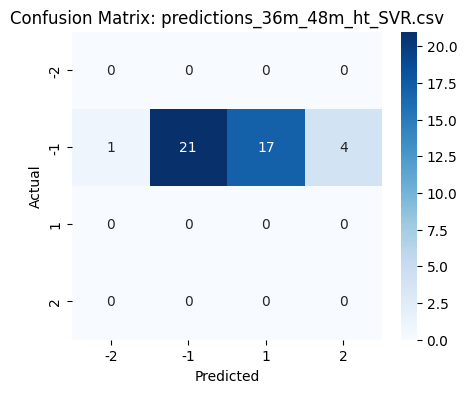

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.49      0.66        43
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.49        43
   macro avg       0.25      0.12      0.16        43
weighted avg       1.00      0.49      0.66        43


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2500997812,1.318770,1.318770,1.121263,0.0,-0.197507,-1,-1
1,6490194309,-1.420569,-1.420569,-1.570266,0.0,-0.149697,-1,-1
2,2501036077,-0.053925,-0.053925,0.211397,0.0,0.265322,-1,1
3,2501013001,-0.818186,-0.818186,-0.904277,0.0,-0.086090,-1,-1
4,2501007379,-0.053925,-0.053925,0.221665,0.0,0.275589,-1,1
5,2501034244,-3.183134,-3.183134,-1.285022,0.0,1.898112,-1,2
6,2501003128,0.449389,0.449389,0.288337,0.0,-0.161052,-1,-1
7,6560209253,-0.598694,-0.598694,-0.583448,0.0,0.015246,-1,1
8,2289112984,-0.307421,-0.307421,-0.411628,0.0,-0.104208,-1,-1
9,2501020316,-0.053925,-0.053925,-0.039459,0.0,0.014466,-1,1



=== predictions_36m_48m_ht_XGBoost.csv ===


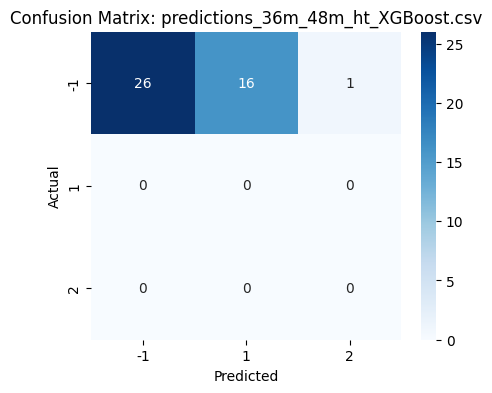

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.60      0.75        43
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.60        43
   macro avg       0.33      0.20      0.25        43
weighted avg       1.00      0.60      0.75        43


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2500997812,1.318770,1.318770,1.191813,0.0,-0.126957,-1,-1
1,6490194309,-1.420569,-1.420569,-1.418475,0.0,0.002094,-1,1
2,2501036077,-0.053925,-0.053925,-0.061180,0.0,-0.007255,-1,-1
3,2501013001,-0.818186,-0.818186,-0.831510,0.0,-0.013323,-1,-1
4,2501007379,-0.053925,-0.053925,-0.063122,0.0,-0.009197,-1,-1
5,2501034244,-3.183134,-3.183134,-3.169991,0.0,0.013143,-1,1
6,2501003128,0.449389,0.449389,0.448112,0.0,-0.001276,-1,-1
7,6560209253,-0.598694,-0.598694,-0.598188,0.0,0.000506,-1,1
8,2289112984,-0.307421,-0.307421,-0.307305,0.0,0.000116,-1,1
9,2501020316,-0.053925,-0.053925,-0.054313,0.0,-0.000388,-1,-1



=== predictions_36m_48m_wt_LinearRegression.csv ===


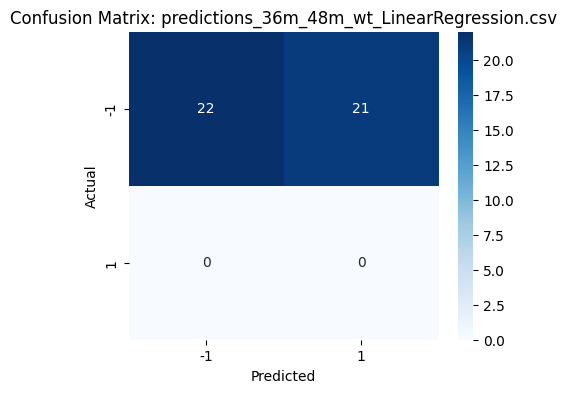

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.51      0.68        43
           1       0.00      0.00      0.00         0

    accuracy                           0.51        43
   macro avg       0.50      0.26      0.34        43
weighted avg       1.00      0.51      0.68        43


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2500997812,0.590267,0.590267,0.590267,0.0,-4.440892e-16,-1,-1
1,6490194309,-3.018532,-3.018532,-3.018532,0.0,-8.881784e-16,-1,-1
2,2501036077,-0.606349,-0.606349,-0.606349,0.0,1.665335e-15,-1,1
3,2501013001,-2.752621,-2.752621,-2.752621,0.0,1.332268e-15,-1,1
4,2501007379,-1.356258,-1.356258,-1.356258,0.0,-6.661338e-16,-1,-1
5,2501034244,-3.312397,-3.312397,-3.312397,0.0,2.220446e-15,-1,1
6,2501003128,-1.275619,-1.275619,-1.275619,0.0,1.110223e-15,-1,1
7,6560209253,-0.945640,-0.945640,-0.945640,0.0,8.881784e-16,-1,1
8,2289112984,-2.543534,-2.543534,-2.543534,0.0,3.552714e-15,-1,1
9,2501020316,-1.780751,-1.780751,-1.780751,0.0,-6.661338e-16,-1,-1



=== predictions_36m_48m_wt_MLP.csv ===


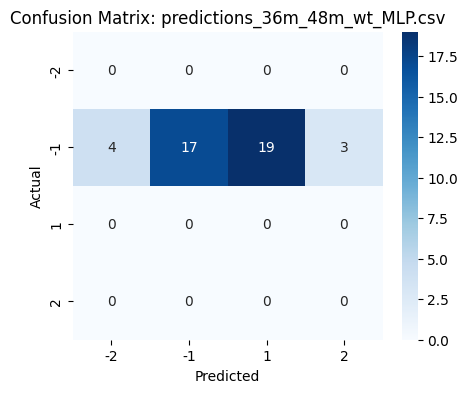

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.40      0.57        43
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.40        43
   macro avg       0.25      0.10      0.14        43
weighted avg       1.00      0.40      0.57        43


Sample rows:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.40      0.57        43
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.40        43
   macro avg       0.25      0.10      0.14        43
weighted avg       1.00      0.40      0.57        43


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2500997812,0.590267,0.590267,0.317739,0.0,-0.272529,-1,-1
1,6490194309,-3.018532,-3.018532,-2.592918,0.0,0.425614,-1,1
2,2501036077,-0.606349,-0.606349,-0.666868,0.0,-0.060518,-1,-1
3,2501013001,-2.752621,-2.752621,-2.981816,0.0,-0.229195,-1,-1
4,2501007379,-1.356258,-1.356258,-0.876267,0.0,0.479991,-1,1
5,2501034244,-3.312397,-3.312397,-3.391850,0.0,-0.079453,-1,-1
6,2501003128,-1.275619,-1.275619,-2.176289,0.0,-0.900670,-1,-2
7,6560209253,-0.945640,-0.945640,-0.740838,0.0,0.204802,-1,1
8,2289112984,-2.543534,-2.543534,-1.877080,0.0,0.666454,-1,1
9,2501020316,-1.780751,-1.780751,-1.468678,0.0,0.312073,-1,1



=== predictions_36m_48m_wt_SVR.csv ===


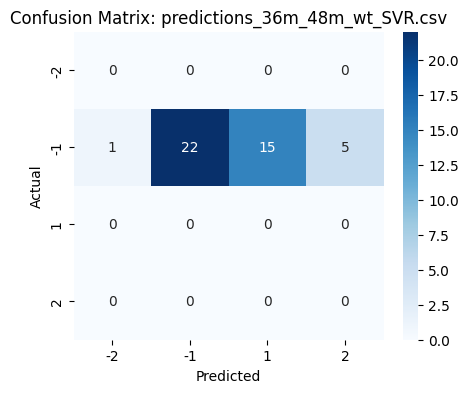

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.51      0.68        43
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.51        43
   macro avg       0.25      0.13      0.17        43
weighted avg       1.00      0.51      0.68        43


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2500997812,0.590267,0.590267,0.299084,0.0,-0.291184,-1,-1
1,6490194309,-3.018532,-3.018532,-3.136205,0.0,-0.117672,-1,-1
2,2501036077,-0.606349,-0.606349,-0.570142,0.0,0.036207,-1,1
3,2501013001,-2.752621,-2.752621,-2.968193,0.0,-0.215572,-1,-1
4,2501007379,-1.356258,-1.356258,-1.106673,0.0,0.249584,-1,1
5,2501034244,-3.312397,-3.312397,-2.215628,0.0,1.096769,-1,2
6,2501003128,-1.275619,-1.275619,-1.586760,0.0,-0.311141,-1,-1
7,6560209253,-0.945640,-0.945640,-0.788916,0.0,0.156724,-1,1
8,2289112984,-2.543534,-2.543534,-2.234523,0.0,0.309011,-1,1
9,2501020316,-1.780751,-1.780751,-1.960701,0.0,-0.179950,-1,-1



=== predictions_36m_48m_wt_XGBoost.csv ===


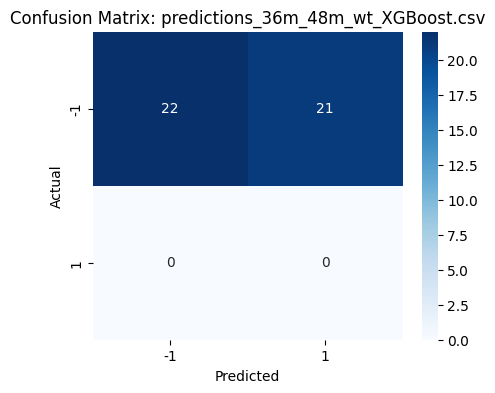

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.51      0.68        43
           1       0.00      0.00      0.00         0

    accuracy                           0.51        43
   macro avg       0.50      0.26      0.34        43
weighted avg       1.00      0.51      0.68        43


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2500997812,0.590267,0.590267,0.597799,0.0,0.007531,-1,1
1,6490194309,-3.018532,-3.018532,-3.118560,0.0,-0.100028,-1,-1
2,2501036077,-0.606349,-0.606349,-0.608938,0.0,-0.002589,-1,-1
3,2501013001,-2.752621,-2.752621,-2.738340,0.0,0.014282,-1,1
4,2501007379,-1.356258,-1.356258,-1.356092,0.0,0.000166,-1,1
5,2501034244,-3.312397,-3.312397,-3.290245,0.0,0.022151,-1,1
6,2501003128,-1.275619,-1.275619,-1.285658,0.0,-0.010039,-1,-1
7,6560209253,-0.945640,-0.945640,-0.942208,0.0,0.003432,-1,1
8,2289112984,-2.543534,-2.543534,-2.613898,0.0,-0.070365,-1,-1
9,2501020316,-1.780751,-1.780751,-1.780139,0.0,0.000612,-1,1



=== predictions_6m_12m_bmi_LinearRegression.csv ===


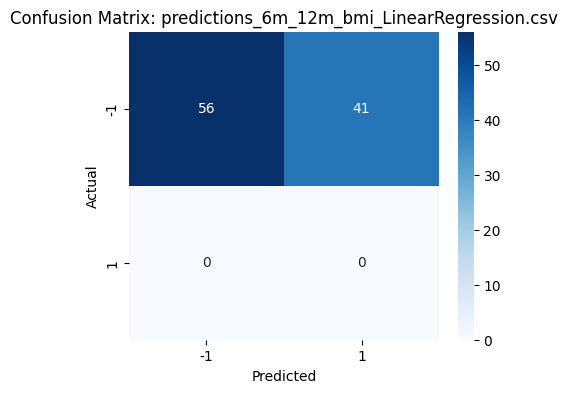

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.58      0.73        97
           1       0.00      0.00      0.00         0

    accuracy                           0.58        97
   macro avg       0.50      0.29      0.37        97
weighted avg       1.00      0.58      0.73        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,-1.068000,-1.068000,-1.068000,0.0,2.220446e-15,-1,1
1,6720211005,-0.998700,-0.998700,-0.998700,0.0,-2.220446e-16,-1,-1
2,2501022531,-2.043578,-2.043578,-2.043578,0.0,-4.440892e-16,-1,-1
3,6560213560,-1.414000,-1.414000,-1.414000,0.0,8.881784e-16,-1,1
4,2501048555,-2.035000,-2.035000,-2.035000,0.0,4.440892e-16,-1,1
5,2501015851,-3.223800,-3.223800,-3.223800,0.0,1.332268e-15,-1,1
6,2501058097,-0.720149,-0.720149,-0.720149,0.0,4.440892e-16,-1,1
7,2501058895,0.759300,0.759300,0.759300,0.0,1.110223e-15,-1,1
8,2501025131,-1.672600,-1.672600,-1.672600,0.0,4.440892e-16,-1,1
9,2501035100,-0.818100,-0.818100,-0.818100,0.0,-3.330669e-16,-1,-1



=== predictions_6m_12m_bmi_MLP.csv ===


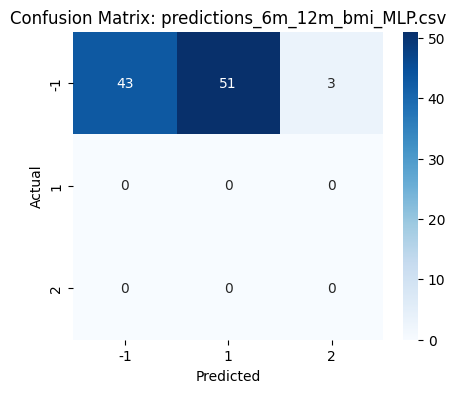

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.44      0.61        97
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.44        97
   macro avg       0.33      0.15      0.20        97
weighted avg       1.00      0.44      0.61        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,-1.068000,-1.068000,-1.298729,0.0,-0.230729,-1,-1
1,6720211005,-0.998700,-0.998700,-0.714104,0.0,0.284596,-1,1
2,2501022531,-2.043578,-2.043578,-1.986313,0.0,0.057266,-1,1
3,6560213560,-1.414000,-1.414000,-1.260438,0.0,0.153562,-1,1
4,2501048555,-2.035000,-2.035000,-1.881852,0.0,0.153148,-1,1
5,2501015851,-3.223800,-3.223800,-3.029842,0.0,0.193958,-1,1
6,2501058097,-0.720149,-0.720149,-0.548715,0.0,0.171433,-1,1
7,2501058895,0.759300,0.759300,0.481047,0.0,-0.278253,-1,-1
8,2501025131,-1.672600,-1.672600,-1.742972,0.0,-0.070372,-1,-1
9,2501035100,-0.818100,-0.818100,-1.126397,0.0,-0.308297,-1,-1



=== predictions_6m_12m_bmi_SVR.csv ===


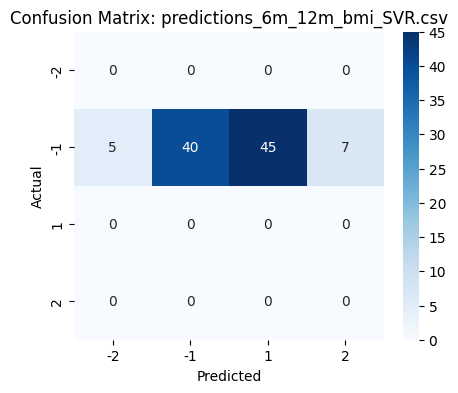

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.41      0.58        97
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.41        97
   macro avg       0.25      0.10      0.15        97
weighted avg       1.00      0.41      0.58        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,-1.068000,-1.068000,-0.991677,0.0,0.076323,-1,1
1,6720211005,-0.998700,-0.998700,-0.982087,0.0,0.016613,-1,1
2,2501022531,-2.043578,-2.043578,-1.984066,0.0,0.059512,-1,1
3,6560213560,-1.414000,-1.414000,-1.398975,0.0,0.015025,-1,1
4,2501048555,-2.035000,-2.035000,-2.065397,0.0,-0.030397,-1,-1
5,2501015851,-3.223800,-3.223800,-3.089741,0.0,0.134059,-1,1
6,2501058097,-0.720149,-0.720149,-0.492552,0.0,0.227597,-1,1
7,2501058895,0.759300,0.759300,0.621094,0.0,-0.138206,-1,-1
8,2501025131,-1.672600,-1.672600,-1.886172,0.0,-0.213572,-1,-1
9,2501035100,-0.818100,-0.818100,-0.931021,0.0,-0.112921,-1,-1



=== predictions_6m_12m_bmi_XGBoost.csv ===


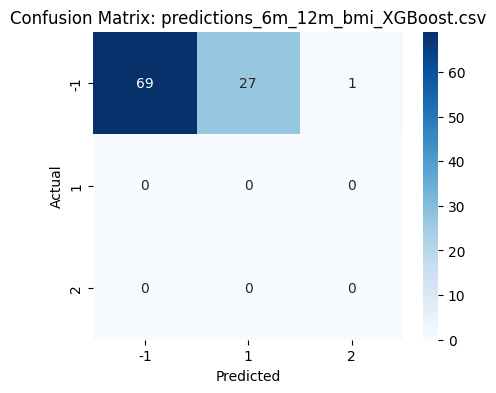

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.71      0.83        97
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.71        97
   macro avg       0.33      0.24      0.28        97
weighted avg       1.00      0.71      0.83        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,-1.068000,-1.068000,-1.084431,0.0,-0.016431,-1,-1
1,6720211005,-0.998700,-0.998700,-1.054167,0.0,-0.055467,-1,-1
2,2501022531,-2.043578,-2.043578,-2.002698,0.0,0.040880,-1,1
3,6560213560,-1.414000,-1.414000,-1.430462,0.0,-0.016462,-1,-1
4,2501048555,-2.035000,-2.035000,-2.025298,0.0,0.009702,-1,1
5,2501015851,-3.223800,-3.223800,-3.400938,0.0,-0.177138,-1,-1
6,2501058097,-0.720149,-0.720149,-0.734359,0.0,-0.014210,-1,-1
7,2501058895,0.759300,0.759300,0.746669,0.0,-0.012631,-1,-1
8,2501025131,-1.672600,-1.672600,-1.681768,0.0,-0.009169,-1,-1
9,2501035100,-0.818100,-0.818100,-0.816364,0.0,0.001736,-1,1



=== predictions_6m_12m_ht_LinearRegression.csv ===


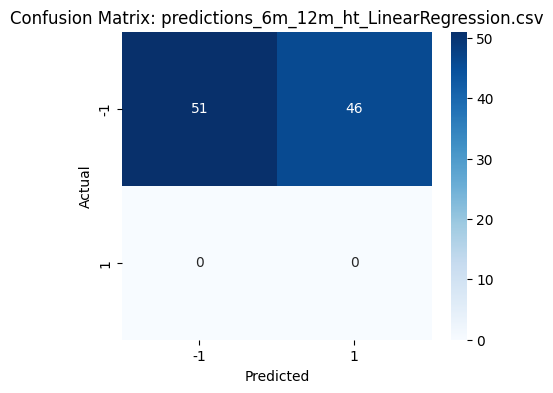

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.53      0.69        97
           1       0.00      0.00      0.00         0

    accuracy                           0.53        97
   macro avg       0.50      0.26      0.34        97
weighted avg       1.00      0.53      0.69        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,0.770000,0.770000,0.770000,0.0,-1.110223e-15,-1,-1
1,6720211005,0.400000,0.400000,0.400000,0.0,2.720046e-15,-1,1
2,2501022531,-2.888642,-2.888642,-2.888642,0.0,-1.776357e-15,-1,-1
3,6560213560,1.870000,1.870000,1.870000,0.0,6.661338e-16,-1,1
4,2501048555,0.170000,0.170000,0.170000,0.0,-1.471046e-15,-1,-1
5,2501015851,-0.770000,-0.770000,-0.770000,0.0,-1.110223e-15,-1,-1
6,2501058097,0.979701,0.979701,0.979701,0.0,-2.220446e-16,-1,-1
7,2501058895,-1.210000,-1.210000,-1.210000,0.0,-2.220446e-16,-1,-1
8,2501025131,0.170000,0.170000,0.170000,0.0,5.828671e-16,-1,1
9,2501035100,0.170000,0.170000,0.170000,0.0,8.604228e-16,-1,1



=== predictions_6m_12m_ht_MLP.csv ===


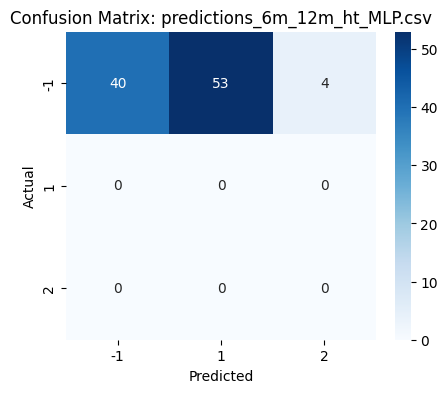

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.41      0.58        97
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.41        97
   macro avg       0.33      0.14      0.19        97
weighted avg       1.00      0.41      0.58        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,0.770000,0.770000,0.642563,0.0,-0.127437,-1,-1
1,6720211005,0.400000,0.400000,0.780158,0.0,0.380158,-1,1
2,2501022531,-2.888642,-2.888642,-1.873382,0.0,1.015260,-1,2
3,6560213560,1.870000,1.870000,1.953222,0.0,0.083222,-1,1
4,2501048555,0.170000,0.170000,0.056493,0.0,-0.113507,-1,-1
5,2501015851,-0.770000,-0.770000,-0.723562,0.0,0.046438,-1,1
6,2501058097,0.979701,0.979701,0.370412,0.0,-0.609289,-1,-1
7,2501058895,-1.210000,-1.210000,-1.356960,0.0,-0.146960,-1,-1
8,2501025131,0.170000,0.170000,0.140302,0.0,-0.029698,-1,-1
9,2501035100,0.170000,0.170000,0.168361,0.0,-0.001639,-1,-1



=== predictions_6m_12m_ht_SVR.csv ===


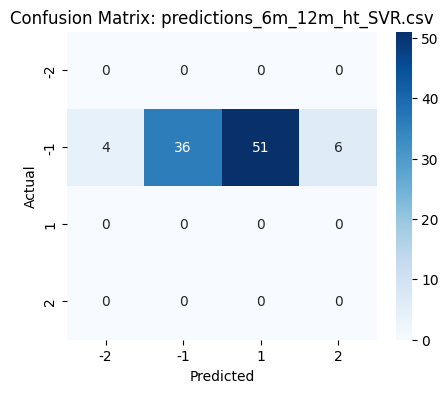

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.37      0.54        97
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.37        97
   macro avg       0.25      0.09      0.14        97
weighted avg       1.00      0.37      0.54        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,0.770000,0.770000,0.550543,0.0,-0.219457,-1,-1
1,6720211005,0.400000,0.400000,0.408862,0.0,0.008862,-1,1
2,2501022531,-2.888642,-2.888642,-1.974328,0.0,0.914314,-1,2
3,6560213560,1.870000,1.870000,1.629634,0.0,-0.240366,-1,-1
4,2501048555,0.170000,0.170000,0.089091,0.0,-0.080909,-1,-1
5,2501015851,-0.770000,-0.770000,-0.834317,0.0,-0.064317,-1,-1
6,2501058097,0.979701,0.979701,0.581874,0.0,-0.397827,-1,-1
7,2501058895,-1.210000,-1.210000,-1.179492,0.0,0.030508,-1,1
8,2501025131,0.170000,0.170000,0.188120,0.0,0.018120,-1,1
9,2501035100,0.170000,0.170000,0.368250,0.0,0.198250,-1,1



=== predictions_6m_12m_ht_XGBoost.csv ===


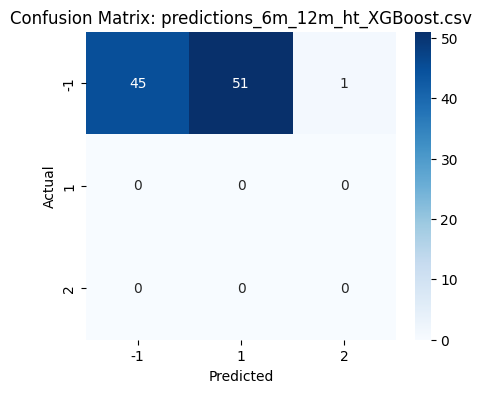

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.46      0.63        97
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.46        97
   macro avg       0.33      0.15      0.21        97
weighted avg       1.00      0.46      0.63        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,0.770000,0.770000,0.770797,0.0,0.000797,-1,1
1,6720211005,0.400000,0.400000,0.413651,0.0,0.013651,-1,1
2,2501022531,-2.888642,-2.888642,-2.893487,0.0,-0.004845,-1,-1
3,6560213560,1.870000,1.870000,1.871302,0.0,0.001302,-1,1
4,2501048555,0.170000,0.170000,0.170661,0.0,0.000661,-1,1
5,2501015851,-0.770000,-0.770000,-0.772088,0.0,-0.002088,-1,-1
6,2501058097,0.979701,0.979701,0.980313,0.0,0.000613,-1,1
7,2501058895,-1.210000,-1.210000,-1.214234,0.0,-0.004234,-1,-1
8,2501025131,0.170000,0.170000,0.165418,0.0,-0.004582,-1,-1
9,2501035100,0.170000,0.170000,0.168168,0.0,-0.001831,-1,-1



=== predictions_6m_12m_wt_LinearRegression.csv ===


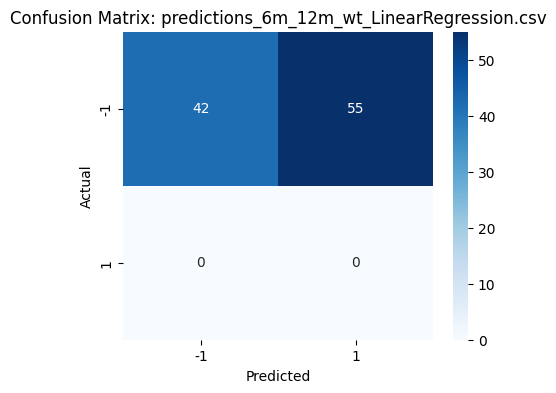

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.43      0.60        97
           1       0.00      0.00      0.00         0

    accuracy                           0.43        97
   macro avg       0.50      0.22      0.30        97
weighted avg       1.00      0.43      0.60        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,-0.350000,-0.350000,-3.500000e-01,0.0,2.053913e-15,-1,1
1,6720211005,-0.520000,-0.520000,-5.200000e-01,0.0,5.551115e-16,-1,1
2,2501022513,-1.400000,-1.400000,-1.400000e+00,0.0,-4.440892e-16,-1,-1
3,6560213560,0.000000,0.000000,-7.771561e-16,0.0,-7.771561e-16,-1,-1
4,6490189399,-1.670000,-1.670000,-1.670000e+00,0.0,-4.440892e-16,-1,-1
5,2501015363,0.830000,0.830000,8.300000e-01,0.0,1.887379e-15,-1,1
6,2501058097,0.034037,0.034037,3.403691e-02,0.0,3.469447e-17,-1,1
7,2501054008,0.430000,0.430000,4.300000e-01,0.0,3.885781e-16,-1,1
8,2501025131,-1.140000,-1.140000,-1.140000e+00,0.0,-2.220446e-16,-1,-1
9,2501035100,-0.520000,-0.520000,-5.200000e-01,0.0,-3.330669e-16,-1,-1



=== predictions_6m_12m_wt_MLP.csv ===


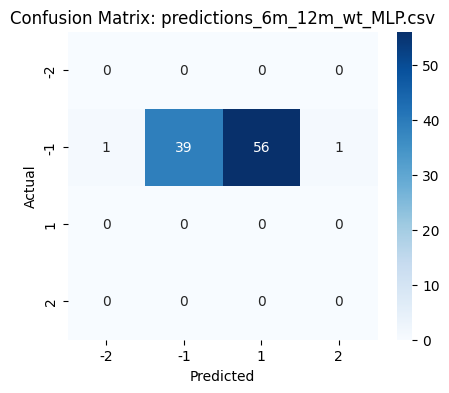

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.40      0.57        97
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.40        97
   macro avg       0.25      0.10      0.14        97
weighted avg       1.00      0.40      0.57        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,-0.350000,-0.350000,-0.659718,0.0,-0.309718,-1,-1
1,6720211005,-0.520000,-0.520000,-0.227583,0.0,0.292417,-1,1
2,2501022513,-1.400000,-1.400000,-1.403730,0.0,-0.003730,-1,-1
3,6560213560,0.000000,0.000000,0.041313,0.0,0.041313,-1,1
4,6490189399,-1.670000,-1.670000,-1.438907,0.0,0.231093,-1,1
5,2501015363,0.830000,0.830000,1.132038,0.0,0.302038,-1,1
6,2501058097,0.034037,0.034037,-0.230737,0.0,-0.264773,-1,-1
7,2501054008,0.430000,0.430000,0.456659,0.0,0.026659,-1,1
8,2501025131,-1.140000,-1.140000,-1.178652,0.0,-0.038652,-1,-1
9,2501035100,-0.520000,-0.520000,-0.664765,0.0,-0.144765,-1,-1



=== predictions_6m_12m_wt_SVR.csv ===


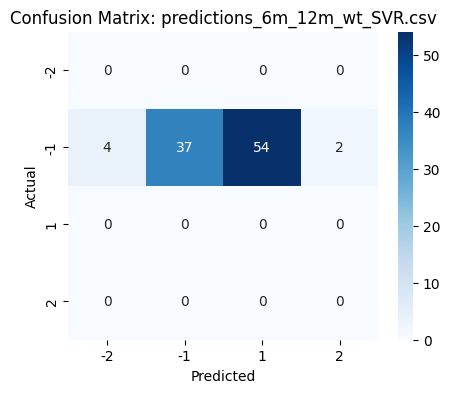

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.38      0.55        97
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.38        97
   macro avg       0.25      0.10      0.14        97
weighted avg       1.00      0.38      0.55        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,-0.350000,-0.350000,-0.525107,0.0,-0.175107,-1,-1
1,6720211005,-0.520000,-0.520000,-0.505505,0.0,0.014495,-1,1
2,2501022513,-1.400000,-1.400000,-1.251161,0.0,0.148839,-1,1
3,6560213560,0.000000,0.000000,-0.173182,0.0,-0.173182,-1,-1
4,6490189399,-1.670000,-1.670000,-1.462103,0.0,0.207897,-1,1
5,2501015363,0.830000,0.830000,0.286069,0.0,-0.543931,-1,-1
6,2501058097,0.034037,0.034037,0.023984,0.0,-0.010053,-1,-1
7,2501054008,0.430000,0.430000,0.396077,0.0,-0.033923,-1,-1
8,2501025131,-1.140000,-1.140000,-1.188776,0.0,-0.048776,-1,-1
9,2501035100,-0.520000,-0.520000,-0.459319,0.0,0.060681,-1,1



=== predictions_6m_12m_wt_XGBoost.csv ===


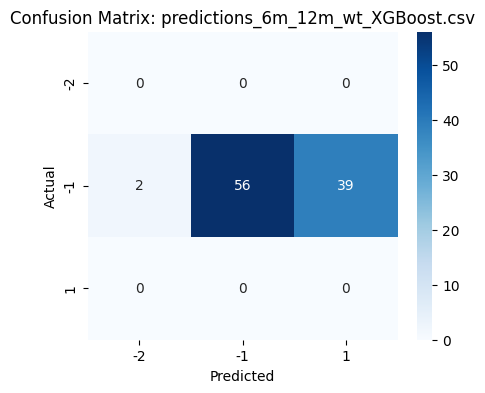

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.58      0.73        97
           1       0.00      0.00      0.00         0

    accuracy                           0.58        97
   macro avg       0.33      0.19      0.24        97
weighted avg       1.00      0.58      0.73        97


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,6490198770,-0.350000,-0.350000,-0.350328,0.0,-0.000328,-1,-1
1,6720211005,-0.520000,-0.520000,-0.517407,0.0,0.002593,-1,1
2,2501022513,-1.400000,-1.400000,-1.372023,0.0,0.027977,-1,1
3,6560213560,0.000000,0.000000,-0.004067,0.0,-0.004067,-1,-1
4,6490189399,-1.670000,-1.670000,-1.673113,0.0,-0.003113,-1,-1
5,2501015363,0.830000,0.830000,0.827574,0.0,-0.002426,-1,-1
6,2501058097,0.034037,0.034037,-0.018349,0.0,-0.052386,-1,-1
7,2501054008,0.430000,0.430000,0.463082,0.0,0.033082,-1,1
8,2501025131,-1.140000,-1.140000,-1.134682,0.0,0.005318,-1,1
9,2501035100,-0.520000,-0.520000,-0.517287,0.0,0.002713,-1,1



=== predictions_birth_6m_bmi_LinearRegression.csv ===


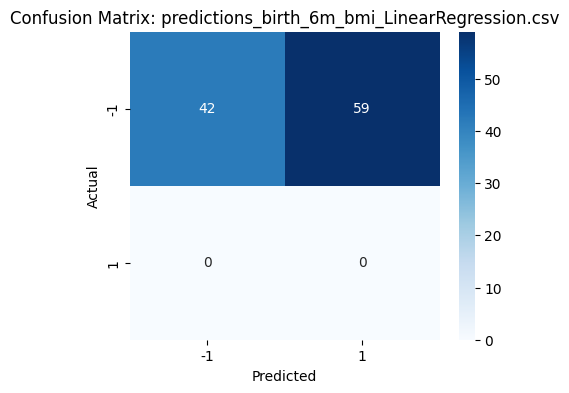

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.42      0.59       101
           1       0.00      0.00      0.00         0

    accuracy                           0.42       101
   macro avg       0.50      0.21      0.29       101
weighted avg       1.00      0.42      0.59       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,-1.746643,-1.746643,-1.746643,0.0,-1.110223e-15,-1,-1
1,2501041313,-1.354075,-1.354075,-1.354075,0.0,-8.881784e-16,-1,-1
2,6710115372,0.003819,0.003819,0.003819,0.0,1.181347e-15,-1,1
3,2461071500,-1.005229,-1.005229,-1.005229,0.0,4.440892e-16,-1,1
4,2501047257,-0.821903,-0.821903,-0.821903,0.0,1.332268e-15,-1,1
5,2461092826,-0.396287,-0.396287,-0.396287,0.0,-4.440892e-16,-1,-1
6,6560227146,-1.662492,-1.662492,-1.662492,0.0,-3.108624e-15,-1,-1
7,2501009657,-0.409926,-0.409926,-0.409926,0.0,1.498801e-15,-1,1
8,6560217000,-3.211606,-3.211606,-3.211606,0.0,-4.440892e-16,-1,-1
9,2501024028,-2.811241,-2.811241,-2.811241,0.0,-4.440892e-16,-1,-1



=== predictions_birth_6m_bmi_MLP.csv ===


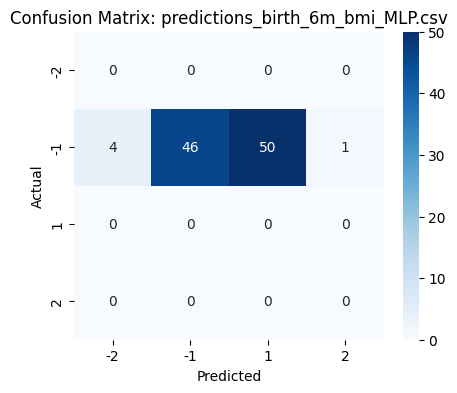

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.46      0.63       101
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.46       101
   macro avg       0.25      0.11      0.16       101
weighted avg       1.00      0.46      0.63       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,-1.746643,-1.746643,-1.636789,0.0,0.109854,-1,1
1,2501041313,-1.354075,-1.354075,-1.303385,0.0,0.050690,-1,1
2,6710115372,0.003819,0.003819,-0.171034,0.0,-0.174853,-1,-1
3,2461071500,-1.005229,-1.005229,-0.927454,0.0,0.077776,-1,1
4,2501047257,-0.821903,-0.821903,-0.755538,0.0,0.066365,-1,1
5,2461092826,-0.396287,-0.396287,-0.291102,0.0,0.105186,-1,1
6,6560227146,-1.662492,-1.662492,-1.717230,0.0,-0.054737,-1,-1
7,2501009657,-0.409926,-0.409926,-0.508962,0.0,-0.099037,-1,-1
8,6560217000,-3.211606,-3.211606,-2.927548,0.0,0.284059,-1,1
9,2501024028,-2.811241,-2.811241,-2.686071,0.0,0.125171,-1,1



=== predictions_birth_6m_bmi_SVR.csv ===


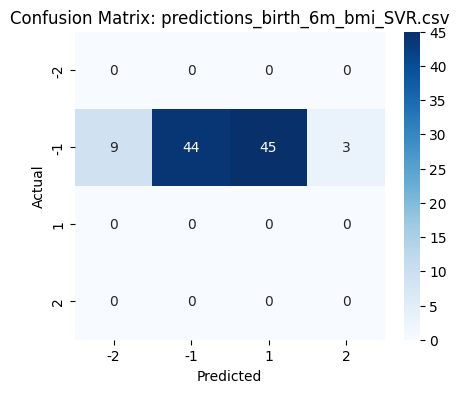

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.44      0.61       101
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.44       101
   macro avg       0.25      0.11      0.15       101
weighted avg       1.00      0.44      0.61       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,-1.746643,-1.746643,-1.857957,0.0,-0.111314,-1,-1
1,2501041313,-1.354075,-1.354075,-1.331938,0.0,0.022137,-1,1
2,6710115372,0.003819,0.003819,-0.331246,0.0,-0.335065,-1,-1
3,2461071500,-1.005229,-1.005229,-0.753444,0.0,0.251785,-1,1
4,2501047257,-0.821903,-0.821903,-0.876905,0.0,-0.055002,-1,-1
5,2461092826,-0.396287,-0.396287,-0.696809,0.0,-0.300522,-1,-1
6,6560227146,-1.662492,-1.662492,-1.381492,0.0,0.281000,-1,1
7,2501009657,-0.409926,-0.409926,-0.765891,0.0,-0.355965,-1,-1
8,6560217000,-3.211606,-3.211606,-3.253260,0.0,-0.041653,-1,-1
9,2501024028,-2.811241,-2.811241,-2.516158,0.0,0.295083,-1,1



=== predictions_birth_6m_bmi_XGBoost.csv ===


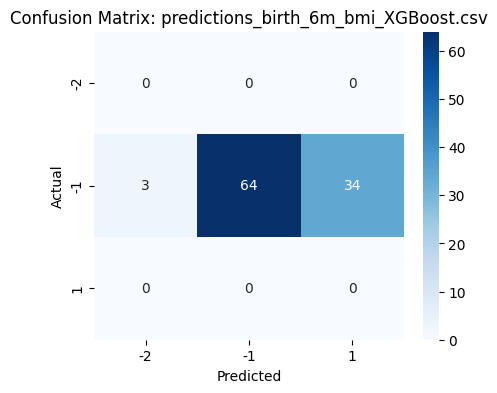

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.63      0.78       101
           1       0.00      0.00      0.00         0

    accuracy                           0.63       101
   macro avg       0.33      0.21      0.26       101
weighted avg       1.00      0.63      0.78       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,-1.746643,-1.746643,-1.730411,0.0,0.016231,-1,1
1,2501041313,-1.354075,-1.354075,-1.354270,0.0,-0.000195,-1,-1
2,6710115372,0.003819,0.003819,0.027597,0.0,0.023778,-1,1
3,2461071500,-1.005229,-1.005229,-1.013780,0.0,-0.008550,-1,-1
4,2501047257,-0.821903,-0.821903,-0.832299,0.0,-0.010397,-1,-1
5,2461092826,-0.396287,-0.396287,-0.404217,0.0,-0.007930,-1,-1
6,6560227146,-1.662492,-1.662492,-1.684043,0.0,-0.021550,-1,-1
7,2501009657,-0.409926,-0.409926,-0.377973,0.0,0.031953,-1,1
8,6560217000,-3.211606,-3.211606,-3.119119,0.0,0.092487,-1,1
9,2501024028,-2.811241,-2.811241,-2.765587,0.0,0.045655,-1,1



=== predictions_birth_6m_ht_LinearRegression.csv ===


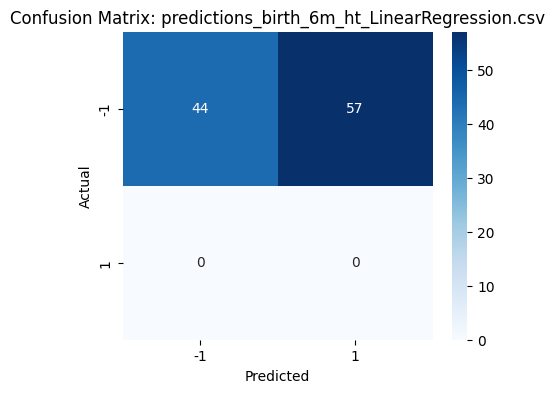

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.44      0.61       101
           1       0.00      0.00      0.00         0

    accuracy                           0.44       101
   macro avg       0.50      0.22      0.30       101
weighted avg       1.00      0.44      0.61       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,1.645867,1.645867,1.645867,0.0,3.108624e-15,-1,1
1,2501041313,3.141840,3.141840,3.141840,0.0,3.552714e-15,-1,1
2,6710115372,0.994417,0.994417,0.994417,0.0,2.109424e-15,-1,1
3,2461071500,-0.616150,-0.616150,-0.616150,0.0,-1.110223e-16,-1,-1
4,2501047257,0.457561,0.457561,0.457561,0.0,4.718448e-15,-1,1
5,2461092826,-0.467064,-0.467064,-0.467064,0.0,-1.831868e-15,-1,-1
6,6560227146,3.230564,3.230564,3.230564,0.0,4.884981e-15,-1,1
7,2501009657,-2.226717,-2.226717,-2.226717,0.0,-3.108624e-15,-1,-1
8,6560217000,3.141840,3.141840,3.141840,0.0,5.329071e-15,-1,1
9,2501024028,1.117634,1.117634,1.117634,0.0,1.332268e-15,-1,1



=== predictions_birth_6m_ht_MLP.csv ===


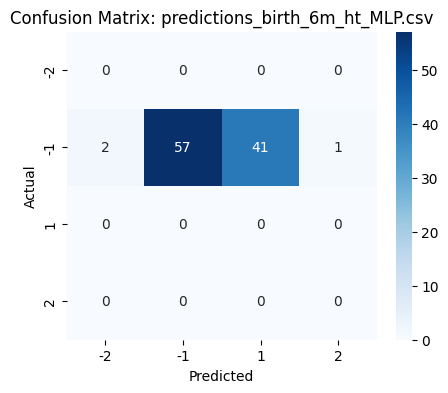

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.56      0.72       101
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.56       101
   macro avg       0.25      0.14      0.18       101
weighted avg       1.00      0.56      0.72       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,1.645867,1.645867,1.667073,0.0,0.021206,-1,1
1,2501041313,3.141840,3.141840,3.306657,0.0,0.164817,-1,1
2,6710115372,0.994417,0.994417,0.675077,0.0,-0.319340,-1,-1
3,2461071500,-0.616150,-0.616150,-0.656624,0.0,-0.040474,-1,-1
4,2501047257,0.457561,0.457561,0.569794,0.0,0.112233,-1,1
5,2461092826,-0.467064,-0.467064,-0.466447,0.0,0.000617,-1,1
6,6560227146,3.230564,3.230564,2.985609,0.0,-0.244955,-1,-1
7,2501009657,-2.226717,-2.226717,-2.152755,0.0,0.073962,-1,1
8,6560217000,3.141840,3.141840,3.222828,0.0,0.080988,-1,1
9,2501024028,1.117634,1.117634,1.100423,0.0,-0.017211,-1,-1



=== predictions_birth_6m_ht_SVR.csv ===


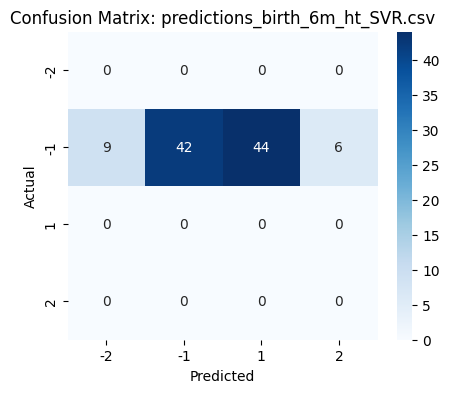

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.42      0.59       101
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.42       101
   macro avg       0.25      0.10      0.15       101
weighted avg       1.00      0.42      0.59       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,1.645867,1.645867,2.017105,0.0,0.371239,-1,1
1,2501041313,3.141840,3.141840,2.380762,0.0,-0.761078,-1,-2
2,6710115372,0.994417,0.994417,1.014343,0.0,0.019926,-1,1
3,2461071500,-0.616150,-0.616150,-0.694912,0.0,-0.078762,-1,-1
4,2501047257,0.457561,0.457561,0.487539,0.0,0.029977,-1,1
5,2461092826,-0.467064,-0.467064,-0.261179,0.0,0.205884,-1,1
6,6560227146,3.230564,3.230564,2.127068,0.0,-1.103497,-1,-2
7,2501009657,-2.226717,-2.226717,-1.671575,0.0,0.555142,-1,1
8,6560217000,3.141840,3.141840,3.231297,0.0,0.089457,-1,1
9,2501024028,1.117634,1.117634,0.936018,0.0,-0.181616,-1,-1



=== predictions_birth_6m_ht_XGBoost.csv ===


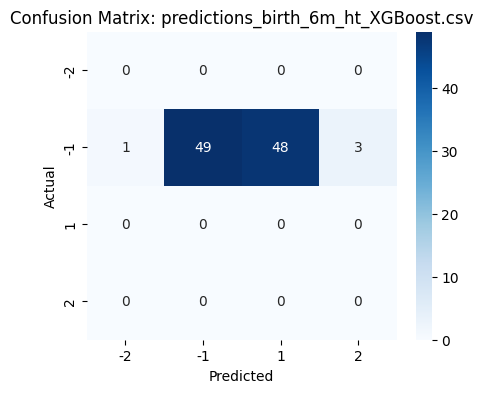

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.49      0.65       101
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.49       101
   macro avg       0.25      0.12      0.16       101
weighted avg       1.00      0.49      0.65       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,1.645867,1.645867,1.646110,0.0,0.000244,-1,1
1,2501041313,3.141840,3.141840,3.141564,0.0,-0.000276,-1,-1
2,6710115372,0.994417,0.994417,0.994193,0.0,-0.000224,-1,-1
3,2461071500,-0.616150,-0.616150,-0.616163,0.0,-0.000013,-1,-1
4,2501047257,0.457561,0.457561,0.457582,0.0,0.000021,-1,1
5,2461092826,-0.467064,-0.467064,-0.466996,0.0,0.000068,-1,1
6,6560227146,3.230564,3.230564,3.996304,0.0,0.765740,-1,2
7,2501009657,-2.226717,-2.226717,-2.228105,0.0,-0.001388,-1,-1
8,6560217000,3.141840,3.141840,3.140887,0.0,-0.000953,-1,-1
9,2501024028,1.117634,1.117634,1.117600,0.0,-0.000034,-1,-1



=== predictions_birth_6m_wt_LinearRegression.csv ===


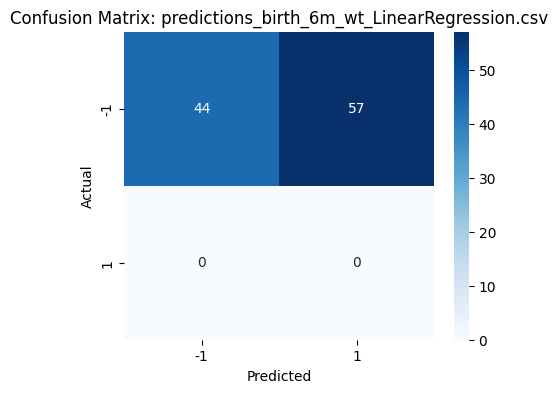

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.44      0.61       101
           1       0.00      0.00      0.00         0

    accuracy                           0.44       101
   macro avg       0.50      0.22      0.30       101
weighted avg       1.00      0.44      0.61       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,-0.303981,-0.303981,-0.303981,0.0,7.216450e-16,-1,1
1,2501041313,0.694352,0.694352,0.694352,0.0,2.553513e-15,-1,1
2,6710115372,0.507799,0.507799,0.507799,0.0,1.998401e-15,-1,1
3,2461071500,-0.985745,-0.985745,-0.985745,0.0,-1.110223e-16,-1,-1
4,2501047257,-0.314788,-0.314788,-0.314788,0.0,5.551115e-16,-1,1
5,2461092826,-0.516862,-0.516862,-0.516862,0.0,5.551115e-16,-1,1
6,6560227146,0.506691,0.506691,0.506691,0.0,2.331468e-15,-1,1
7,2501009657,-1.473952,-1.473952,-1.473952,0.0,-2.220446e-15,-1,-1
8,6560217000,-0.518680,-0.518680,-0.518680,0.0,-2.220446e-16,-1,-1
9,2501024028,-1.183661,-1.183661,-1.183661,0.0,4.440892e-16,-1,1



=== predictions_birth_6m_wt_MLP.csv ===


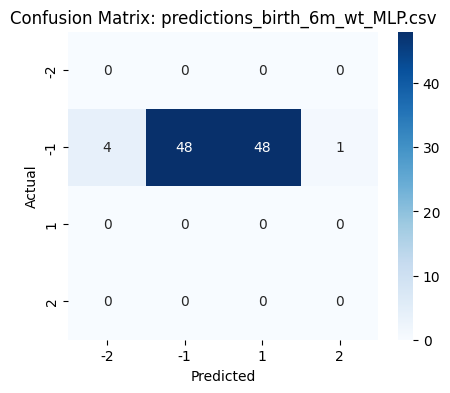

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.48      0.64       101
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.48       101
   macro avg       0.25      0.12      0.16       101
weighted avg       1.00      0.48      0.64       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,-0.303981,-0.303981,-0.283769,0.0,0.020212,-1,1
1,2501041313,0.694352,0.694352,0.927850,0.0,0.233497,-1,1
2,6710115372,0.507799,0.507799,0.251660,0.0,-0.256138,-1,-1
3,2461071500,-0.985745,-0.985745,-1.005318,0.0,-0.019573,-1,-1
4,2501047257,-0.314788,-0.314788,-0.154397,0.0,0.160391,-1,1
5,2461092826,-0.516862,-0.516862,-0.461487,0.0,0.055375,-1,1
6,6560227146,0.506691,0.506691,0.308655,0.0,-0.198036,-1,-1
7,2501009657,-1.473952,-1.473952,-1.425315,0.0,0.048637,-1,1
8,6560217000,-0.518680,-0.518680,-0.403557,0.0,0.115123,-1,1
9,2501024028,-1.183661,-1.183661,-1.230066,0.0,-0.046405,-1,-1



=== predictions_birth_6m_wt_SVR.csv ===


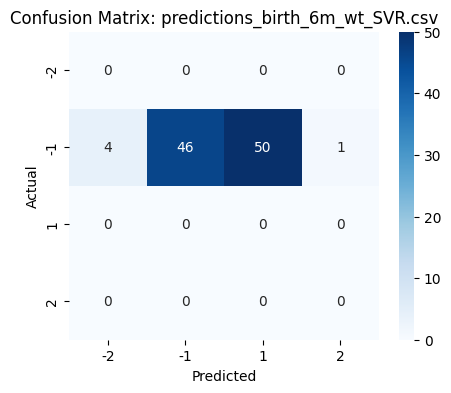

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.46      0.63       101
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0

    accuracy                           0.46       101
   macro avg       0.25      0.11      0.16       101
weighted avg       1.00      0.46      0.63       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,-0.303981,-0.303981,-0.223346,0.0,0.080634,-1,1
1,2501041313,0.694352,0.694352,0.392153,0.0,-0.302199,-1,-1
2,6710115372,0.507799,0.507799,0.306935,0.0,-0.200864,-1,-1
3,2461071500,-0.985745,-0.985745,-0.845540,0.0,0.140205,-1,1
4,2501047257,-0.314788,-0.314788,-0.369011,0.0,-0.054223,-1,-1
5,2461092826,-0.516862,-0.516862,-0.501923,0.0,0.014939,-1,1
6,6560227146,0.506691,0.506691,0.173315,0.0,-0.333376,-1,-1
7,2501009657,-1.473952,-1.473952,-1.459175,0.0,0.014777,-1,1
8,6560217000,-0.518680,-0.518680,-0.465934,0.0,0.052746,-1,1
9,2501024028,-1.183661,-1.183661,-1.095332,0.0,0.088329,-1,1



=== predictions_birth_6m_wt_XGBoost.csv ===


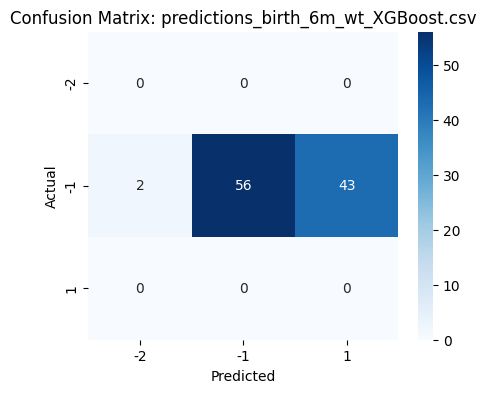

Classification report:
              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         0
          -1       1.00      0.55      0.71       101
           1       0.00      0.00      0.00         0

    accuracy                           0.55       101
   macro avg       0.33      0.18      0.24       101
weighted avg       1.00      0.55      0.71       101


Sample rows:


,national_id,z_current,z_actual,z_pred,delta_true,delta_pred,class_true,class_pred
0,2501018095,-0.303981,-0.303981,-0.304014,0.0,-0.000033,-1,-1
1,2501041313,0.694352,0.694352,0.566858,0.0,-0.127494,-1,-1
2,6710115372,0.507799,0.507799,0.505089,0.0,-0.002709,-1,-1
3,2461071500,-0.985745,-0.985745,-0.986037,0.0,-0.000292,-1,-1
4,2501047257,-0.314788,-0.314788,-0.321674,0.0,-0.006886,-1,-1
5,2461092826,-0.516862,-0.516862,-0.516699,0.0,0.000163,-1,1
6,6560227146,0.506691,0.506691,0.487104,0.0,-0.019587,-1,-1
7,2501009657,-1.473952,-1.473952,-1.473260,0.0,0.000692,-1,1
8,6560217000,-0.518680,-0.518680,-0.514850,0.0,0.003830,-1,1
9,2501024028,-1.183661,-1.183661,-1.180621,0.0,0.003040,-1,1


In [20]:
# Visualize pipeline results: metrics table and confusion matrices

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display

out_dir = Path('pipeline_outputs')
metrics_file = out_dir / 'metrics_summary_all_transitions.csv'

plt.rcParams.update({'figure.max_open_warning': 20})

if not out_dir.exists():
    print("No pipeline_outputs directory found. Run the pipeline first (python train_and_evaluate.py) and re-run this cell.")
else:
    if metrics_file.exists():
        metrics = pd.read_csv(metrics_file)
        print('\nCombined metrics (sorted):')
        display(metrics.sort_values(['transition','measure','model'], ascending=[True,True,True]).reset_index(drop=True))

        # quick pivot showing f1_macro per model for each transition+measure
        try:
            pivot = metrics.pivot_table(index=['transition','measure'], columns='model', values='f1_macro')
            print('\nPivot table (f1_macro):')
            display(pivot)
        except Exception as e:
            print('Could not build pivot table:', e)
    else:
        print('No combined metrics file found at', metrics_file)

    # locate prediction files
    pred_files = sorted(out_dir.glob('predictions_*.csv'))
    if not pred_files:
        print('No per-sample prediction files found in pipeline_outputs.')
    else:
        for pf in pred_files:
            print('\n===', pf.name, '===')
            try:
                df = pd.read_csv(pf)
            except Exception as e:
                print('Failed to read', pf, e)
                continue
            if 'class_true' not in df.columns or 'class_pred' not in df.columns:
                print("File does not contain class_true/class_pred columns. Showing head instead.")
                display(df.head())
                continue
            df = df.dropna(subset=['class_true','class_pred'])
            if df.empty:
                print('No valid rows with class labels in', pf.name)
                continue

            # enforce label ordering
            labels = [-2, -1, 1, 2]
            present_labels = [l for l in labels if (l in df['class_true'].unique()) or (l in df['class_pred'].unique())]
            if not present_labels:
                present_labels = sorted(pd.unique(df['class_true'].tolist() + df['class_pred'].tolist()))

            cm = confusion_matrix(df['class_true'], df['class_pred'], labels=present_labels)
            cm_df = pd.DataFrame(cm, index=present_labels, columns=present_labels)

            plt.figure(figsize=(5,4))
            sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix: {pf.name}')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.show()

            print('Classification report:')
            print(classification_report(df['class_true'], df['class_pred'], zero_division=0))
            print('\nSample rows:')
            display(df.head(10))
